# LLM-Based Vulnerability Detection: Comprehensive Performance Analysis

## Abstract
This notebook presents a comprehensive analysis of Large Language Model (LLM) performance in vulnerability detection across multiple benchmark datasets: CASTLE, JitVul, and VulBench. We evaluate various LLMs on their ability to identify security vulnerabilities in source code, with particular emphasis on critical metrics such as false negative rates, accuracy, and computational efficiency.

## Research Objectives
1. **Performance Comparison**: Compare different LLMs across vulnerability detection benchmarks
2. **False Negative Analysis**: Examine critical false negative rates (missed vulnerabilities)
3. **Efficiency Evaluation**: Assess accuracy-to-time ratio for optimal model selection
4. **Cross-Dataset Analysis**: Understand model performance across different vulnerability types
5. **Scientific Publication**: Generate publication-quality visualizations with proper annotations

## Methodology
We analyze three experiment types:
- **Binary Classification**: Vulnerable vs. Safe code detection
- **Multiclass Classification**: Multi-category vulnerability classification  
- **CWE-Specific Analysis**: Targeted detection of specific Common Weakness Enumeration types

---

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import glob
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up plotting parameters for publication-quality figures
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

# Color palette for consistent visualization
colors = ['#2E8B57', '#FF6347', '#4169E1', '#FFD700', '#8A2BE2', '#FF1493', '#00CED1', '#FF8C00']
sns.set_palette(colors)

print("✅ Libraries imported successfully")
print("✅ Plotting parameters configured for publication quality")

✅ Libraries imported successfully
✅ Plotting parameters configured for publication quality


In [2]:
# Install required packages
import subprocess
import sys

def install_package(package):
    try:
        __import__(package)
        print(f"✓ {package} already installed")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"✓ {package} installed successfully")

# Install required packages
packages = ['matplotlib', 'seaborn', 'plotly']
for package in packages:
    install_package(package)

print("\nAll packages ready!")

✓ matplotlib already installed
✓ seaborn already installed
✓ plotly already installed

All packages ready!


In [3]:
# Data Loading and Processing Functions (Robust Version)

def safe_get(data, *keys, default=0):
    """Safely get nested dictionary values with default fallback"""
    for key in keys:
        if isinstance(data, dict) and key in data:
            data = data[key]
        else:
            return default
    return data

def load_castle_results():
    """Load and process CASTLE experiment results"""
    castle_results = []
    castle_dir = Path('results/castle_experiments')
    
    if not castle_dir.exists():
        print("Warning: CASTLE results directory not found")
        return pd.DataFrame()
    
    for exp_dir in castle_dir.glob('plan_*'):
        results_file = exp_dir / 'experiment_plan_results.json'
        if results_file.exists():
            try:
                with open(results_file, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                    for exp in data.get('experiments', []):
                        if exp.get('status') == 'success' and 'results' in exp:
                            metrics = exp['results'].get('metrics', {})
                            
                            # Parse experiment name
                            name_parts = exp['experiment_name'].split('_')
                            model = name_parts[0] if len(name_parts) > 0 else 'unknown'
                            exp_type = name_parts[1] if len(name_parts) > 1 else 'unknown'
                            task_type = name_parts[2] if len(name_parts) > 2 else 'all'
                            
                            result = {
                                'dataset': 'CASTLE',
                                'model': model,
                                'experiment_type': exp_type,
                                'task_type': task_type,
                                'accuracy': safe_get(exp, 'results', 'accuracy', default=0),
                                'precision': safe_get(metrics, 'precision', default=0),
                                'recall': safe_get(metrics, 'recall', default=0),
                                'f1_score': safe_get(metrics, 'f1_score', default=0),
                                'specificity': safe_get(metrics, 'specificity', default=0),
                                'true_positives': safe_get(metrics, 'true_positives', default=0),
                                'true_negatives': safe_get(metrics, 'true_negatives', default=0),
                                'false_positives': safe_get(metrics, 'false_positives', default=0),
                                'false_negatives': safe_get(metrics, 'false_negatives', default=0),
                                'total_samples': safe_get(exp, 'results', 'total_samples', default=0),
                                'total_time': safe_get(exp, 'results', 'total_time', default=0),
                                'experiment_name': exp['experiment_name']
                            }
                            
                            # Calculate derived metrics
                            tp_fn = result['true_positives'] + result['false_negatives']
                            result['false_negative_rate'] = result['false_negatives'] / tp_fn if tp_fn > 0 else 0
                            result['accuracy_per_time'] = result['accuracy'] / (result['total_time'] / 60) if result['total_time'] > 0 else 0
                            castle_results.append(result)
            except Exception as e:
                print(f"Error loading {results_file}: {e}")
                continue
    
    return pd.DataFrame(castle_results)

def load_jitvul_results():
    """Load and process JitVul experiment results"""
    jitvul_results = []
    jitvul_dir = Path('results/jitvul_experiments')
    
    if not jitvul_dir.exists():
        print("Warning: JitVul results directory not found")
        return pd.DataFrame()
    
    # Load from summary files first
    for summary_file in jitvul_dir.glob('plan_*.json'):
        try:
            with open(summary_file, 'r', encoding='utf-8') as f:
                data = json.load(f)
                for exp in data:
                    if exp.get('status') == 'success' and 'output_dir' in exp:
                        # Load detailed results from individual experiment directories
                        exp_dir = Path(exp['output_dir'])
                        results_file = exp_dir / 'results.json'
                        if results_file.exists():
                            try:
                                with open(results_file, 'r', encoding='utf-8') as rf:
                                    detailed_results = json.load(rf)
                                    metrics = detailed_results.get('metrics', {})
                                    
                                    # Parse experiment name
                                    name_parts = exp['experiment_name'].split('_')
                                    model = name_parts[0] if len(name_parts) > 0 else 'unknown'
                                    exp_type = name_parts[1] if len(name_parts) > 1 else 'unknown'
                                    task_type = name_parts[2] if len(name_parts) > 2 else 'all'
                                    
                                    result = {
                                        'dataset': 'JitVul',
                                        'model': model,
                                        'experiment_type': exp_type,
                                        'task_type': task_type,
                                        'accuracy': safe_get(detailed_results, 'accuracy', default=0),
                                        'precision': safe_get(metrics, 'precision', default=0),
                                        'recall': safe_get(metrics, 'recall', default=0),
                                        'f1_score': safe_get(metrics, 'f1_score', default=0),
                                        'specificity': safe_get(metrics, 'specificity', default=0),
                                        'true_positives': safe_get(metrics, 'true_positives', default=0),
                                        'true_negatives': safe_get(metrics, 'true_negatives', default=0),
                                        'false_positives': safe_get(metrics, 'false_positives', default=0),
                                        'false_negatives': safe_get(metrics, 'false_negatives', default=0),
                                        'total_samples': safe_get(detailed_results, 'total_samples', default=0),
                                        'total_time': safe_get(detailed_results, 'total_time', default=0),
                                        'experiment_name': exp['experiment_name']
                                    }
                                    
                                    # Calculate derived metrics
                                    tp_fn = result['true_positives'] + result['false_negatives']
                                    result['false_negative_rate'] = result['false_negatives'] / tp_fn if tp_fn > 0 else 0
                                    result['accuracy_per_time'] = result['accuracy'] / (result['total_time'] / 60) if result['total_time'] > 0 else 0
                                    jitvul_results.append(result)
                            except Exception as e:
                                print(f"Error loading detailed results for {exp['experiment_name']}: {e}")
                                continue
        except Exception as e:
            print(f"Error loading {summary_file}: {e}")
            continue
    
    return pd.DataFrame(jitvul_results)

def load_vulbench_results():
    """Load and process VulBench experiment results"""
    vulbench_results = []
    vulbench_dir = Path('results/vulbench_experiments')
    
    if not vulbench_dir.exists():
        print("Warning: VulBench results directory not found")
        return pd.DataFrame()
    
    for exp_dir in vulbench_dir.glob('vulbench_plan_*'):
        plan_file = exp_dir / 'experiment_plan_results.json'
        if plan_file.exists():
            try:
                with open(plan_file, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                    for exp in data.get('experiments', []):
                        if exp.get('status') == 'success' and 'results_file' in exp:
                            results_file = Path(exp['results_file'])
                            if results_file.exists():
                                try:
                                    with open(results_file, 'r', encoding='utf-8') as rf:
                                        detailed_results = json.load(rf)
                                        metrics = detailed_results.get('metrics', {})
                                        
                                        # Parse experiment name
                                        name_parts = exp['experiment_name'].split('_')
                                        model = name_parts[0] if len(name_parts) > 0 else 'unknown'
                                        exp_type = name_parts[1] if len(name_parts) > 1 else 'unknown'
                                        task_type = name_parts[2] if len(name_parts) > 2 else 'all'
                                        
                                        result = {
                                            'dataset': 'VulBench',
                                            'model': model,
                                            'experiment_type': exp_type,
                                            'task_type': task_type,
                                            'accuracy': safe_get(detailed_results, 'accuracy', default=0),
                                            'precision': safe_get(metrics, 'precision', default=0),
                                            'recall': safe_get(metrics, 'recall', default=0),
                                            'f1_score': safe_get(metrics, 'f1_score', default=0),
                                            'specificity': safe_get(metrics, 'specificity', default=0),
                                            'true_positives': safe_get(metrics, 'true_positives', default=0),
                                            'true_negatives': safe_get(metrics, 'true_negatives', default=0),
                                            'false_positives': safe_get(metrics, 'false_positives', default=0),
                                            'false_negatives': safe_get(metrics, 'false_negatives', default=0),
                                            'total_samples': safe_get(detailed_results, 'total_samples', default=0),
                                            'total_time': safe_get(detailed_results, 'total_time', default=0),
                                            'experiment_name': exp['experiment_name']
                                        }
                                        
                                        # Calculate derived metrics
                                        tp_fn = result['true_positives'] + result['false_negatives']
                                        result['false_negative_rate'] = result['false_negatives'] / tp_fn if tp_fn > 0 else 0
                                        result['accuracy_per_time'] = result['accuracy'] / (result['total_time'] / 60) if result['total_time'] > 0 else 0
                                        vulbench_results.append(result)
                                except Exception as e:
                                    print(f"Error loading detailed results: {e}")
                                    continue
            except Exception as e:
                print(f"Error loading {plan_file}: {e}")
                continue
    
    return pd.DataFrame(vulbench_results)

def load_cvefixes_results():
    cvefixes_results = []
    cvefixes_dir = Path('results/cvefixes_experiments')
    
    if not cvefixes_dir.exists():
        print("Warning: CVEFixes results directory not found")
        return pd.DataFrame()
    
    for exp_dir in cvefixes_dir.glob('plan_*'):
        plan_file = exp_dir / 'experiment_plan_results.json'
        if plan_file.exists():
            try:
                with open(plan_file, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                    for exp in data.get('experiments', []):
                        if not(exp.get('status') == 'success' and 'output_dir' in exp):
                            continue
                        experiment_data = json.loads((Path(exp['output_dir']) / 'results.json').read_text())
                        
                        # Parse experiment name
                        name_parts = exp['experiment_name'].split('_')
                        model = name_parts[0] if len(name_parts) > 0 else 'unknown'
                        exp_type = name_parts[1] if len(name_parts) > 1 else 'unknown'
                        task_type = name_parts[2] if len(name_parts) > 2 else 'all'
                        
                        result = {
                            'dataset': 'CVEFixes',
                            'model': model,
                            'experiment_type': exp_type,
                            'task_type': task_type,
                            'accuracy': safe_get(experiment_data, 'accuracy', default=0),
                            'precision': safe_get(experiment_data, 'metrics', 'precision', default=0),
                            'recall': safe_get(experiment_data, 'metrics', 'recall', default=0),
                            'f1_score': safe_get(experiment_data, 'metrics', 'f1_score', default=0),
                            'specificity': safe_get(experiment_data, 'metrics', 'specificity', default=0),
                            'true_positives': safe_get(experiment_data, 'metrics', 'true_positives', default=0),
                            'true_negatives': safe_get(experiment_data, 'metrics', 'true_negatives', default=0),
                            'false_positives': safe_get(experiment_data,'metrics',  'false_positives', default=0),
                            'false_negatives': safe_get(experiment_data,'metrics',  'false_negatives', default=0),
                            'total_samples': safe_get(exp, 'total_samples', default=0),
                            'total_time': safe_get(exp, 'total_time', default=0),
                            'experiment_name': exp['experiment_name']
                        }
                        
                        # Calculate derived metrics
                        tp_fn = result['true_positives'] + result['false_negatives']
                        result['false_negative_rate'] = result['false_negatives'] / tp_fn if tp_fn > 0 else 0
                        result['accuracy_per_time'] = result['accuracy'] / (result['total_time'] / 60) if result['total_time'] > 0 else 0
                        cvefixes_results.append(result)
            except Exception as e:
                print(f"Error loading {plan_file}: {e}")
                continue
            
    return pd.DataFrame(cvefixes_results)
        
def load_vuldetectbench_results():
    """Load and process VulDetectBench experiment results"""
    vuldetectbench_results = []
    vuldetectbench_dir = Path('results/vuldetectbench_experiments')

    
    if not vuldetectbench_dir.exists():
        print("Warning: VulDetectBench results directory not found")
        return pd.DataFrame()
    
    for exp_dir in vuldetectbench_dir.glob('vuldetectbench_plan_*'):
        for experiment_dir in exp_dir.iterdir():
            if (experiment_dir.parts[-2][experiment_dir.parts[-2].index("task") + 4]) in ["3", "4", "5"]:
                continue
            plan_file = experiment_dir / 'results.json' 
            if plan_file.exists():
                try:
                    with open(plan_file, 'r', encoding='utf-8') as f:
                        data = json.load(f)
                        for idx, exp in enumerate(data.get('experiments', [])):
                            if not (exp.get('status') == 'success' and 'metrics' in exp):
                                continue
                            metrics = exp["metrics"]
                            
                            result = {
                                'dataset': 'VulDetectBench',
                                'model': exp['model_name'],
                                'experiment_type': 'binary',
                                'task_type': exp['task_type'],
                                'accuracy': safe_get(exp, 'accuracy', default=0),
                                'precision': safe_get(metrics, 'precision', default=0),
                                'recall': safe_get(metrics, 'recall', default=0),
                                'f1_score': safe_get(metrics, 'f1_score', default=0),
                                'specificity': safe_get(metrics, 'specificity', default=0),
                                'true_positives': safe_get(metrics, 'true_positives', default=0),
                                'true_negatives': safe_get(metrics, 'true_negatives', default=0),
                                'false_positives': safe_get(metrics, 'false_positives', default=0),
                                'false_negatives': safe_get(metrics, 'false_negatives', default=0),
                                'total_samples': safe_get(exp, 'total_samples', default=0),
                                'total_time': safe_get(exp, 'total_time', default=0),
                                'experiment_name': f"{exp['model_name']}_{exp['dataset_path'].split('/')[-1].strip('.json')}"
                            }
                            
                            # Calculate derived metrics
                            tp_fn = result['true_positives'] + result['false_negatives']
                            result['false_negative_rate'] = result['false_negatives'] / tp_fn if tp_fn > 0 else 0
                            result['accuracy_per_time'] = result['accuracy'] / (result['total_time'] / 60) if result['total_time'] > 0 else 0
                            vuldetectbench_results.append(result)
                except Exception as e:
                    print(f"Error loading {plan_file}: {e}")
                    continue
            
    return pd.DataFrame(vuldetectbench_results)

def combine_all_results():
    """Combine results from all datasets"""
    print("Loading CASTLE results...")
    castle_df = load_castle_results()
    print(f"Loaded {len(castle_df)} CASTLE experiments")
    
    print("Loading JitVul results...")
    jitvul_df = load_jitvul_results()
    print(f"Loaded {len(jitvul_df)} JitVul experiments")
    
    print("Loading VulBench results...")
    vulbench_df = load_vulbench_results()
    print(f"Loaded {len(vulbench_df)} VulBench experiments")
    
    print("Loading CVEFixes results...")
    cvefixes_df = load_cvefixes_results()
    print(f"Loaded {len(cvefixes_df)} CVEFixes experiments")
    
    print("Loading VulDetectBench results...")
    vuldetectbench_df = load_vuldetectbench_results()
    print(f"Loaded {len(vuldetectbench_df)} VulDetectBench experiments")
    
    # Combine all dataframes
    all_results = pd.concat([castle_df, jitvul_df, vulbench_df, cvefixes_df], ignore_index=True)
    
    if len(all_results) == 0:
        print("Warning: No experimental data found!")
        return pd.DataFrame()
    
    # Clean model names for better visualization
    all_results['model_clean'] = all_results['model'].str.replace('-', '_').str.replace('.', '_')
    
    # Categorize models by size
    def categorize_model_size(model_name):
        model_lower = model_name.lower()
        if any(size in model_lower for size in ['1b', '1.5b', '3b', '4b', '7b', '8b']):
            return 'Small (≤4B)'
        elif any(size in model_lower for size in ['16b', '27b', '30b']):
            return 'Large (≥16B)'
        else:
            return 'Medium'
    
    all_results['model_size'] = all_results['model'].apply(categorize_model_size)
    
    return all_results

print("Robust data loading functions defined successfully!")

Robust data loading functions defined successfully!


The efficiency metric is calculated as:

$$\text{Efficiency} = \frac{\text{accuracy}}{\frac{\text{total\_time}}{60}} = \frac{60 \cdot \text{accuracy}}{\text{total\_time}}$$

where:
- `accuracy` is the model's accuracy score (0-1)
- `total_time` is the processing time in seconds
- The result represents accuracy per minute

In [4]:
# Load and Analyze All Experimental Results

# Load all experimental data
all_results_df = combine_all_results()
# Filter out all except small
all_results_df = all_results_df[all_results_df['model_size'] == 'Small (≤4B)'][~all_results_df['model'].isin(["gemma3-1b", "deepseek-r1-distill-qwen2.5-1.5b", "gemma3-27b"])]
# rename model_name deepseek-r1-distill-qwen2.5-7b to deepseek-r1-7b
all_results_df['model'] = all_results_df['model'].replace("deepseek-r1-distill-qwen2.5-7b", "deepseek-r1-7b")

# Display basic statistics
print("\n=== EXPERIMENTAL DATASET OVERVIEW ===")
print(f"Total experiments: {len(all_results_df)}")
print(f"Unique models: {all_results_df['model'].nunique()}")
print(f"Datasets: {all_results_df['dataset'].unique()}")
print(f"Experiment types: {all_results_df['experiment_type'].unique()}")

# Summary by dataset
print("\n=== RESULTS BY DATASET ===")
dataset_summary = all_results_df.groupby('dataset').agg({
    'accuracy': ['mean', 'std', 'count'],
    'false_negative_rate': ['mean', 'std'],
    'total_time': ['mean', 'std']
}).round(4)

print(dataset_summary)

# Summary by model
print("\n=== RESULTS BY MODEL ===")
model_summary = all_results_df.groupby('model').agg({
    'accuracy': ['mean', 'std', 'count'],
    'false_negative_rate': ['mean', 'std'],
    'total_time': ['mean', 'std']
}).round(4)

print(model_summary.head(10))

# Display the first few rows to verify data structure
print("\n=== SAMPLE DATA ===")
print(all_results_df[['dataset', 'model', 'experiment_type', 'accuracy', 'false_negative_rate', 'total_time']].head(10))

Loading CASTLE results...
Loaded 99 CASTLE experiments
Loading JitVul results...
Loaded 72 JitVul experiments
Loading VulBench results...
Loaded 92 VulBench experiments
Loading CVEFixes results...
Loaded 70 CVEFixes experiments
Loading VulDetectBench results...
Loaded 0 VulDetectBench experiments

=== EXPERIMENTAL DATASET OVERVIEW ===
Total experiments: 281
Unique models: 7
Datasets: ['CASTLE' 'JitVul' 'VulBench' 'CVEFixes']
Experiment types: ['binary' 'cwe' 'multiclass']

=== RESULTS BY DATASET ===
         accuracy               false_negative_rate         total_time  \
             mean     std count                mean     std       mean   
dataset                                                                  
CASTLE     0.4445  0.2332    69              0.1836  0.2059   952.0178   
CVEFixes   0.4113  0.3634    70              0.1169  0.2779  2953.8709   
JitVul     0.4230  0.1677    60              0.3582  0.3924  2776.8519   
VulBench   0.4686  0.1692    48              0.0770

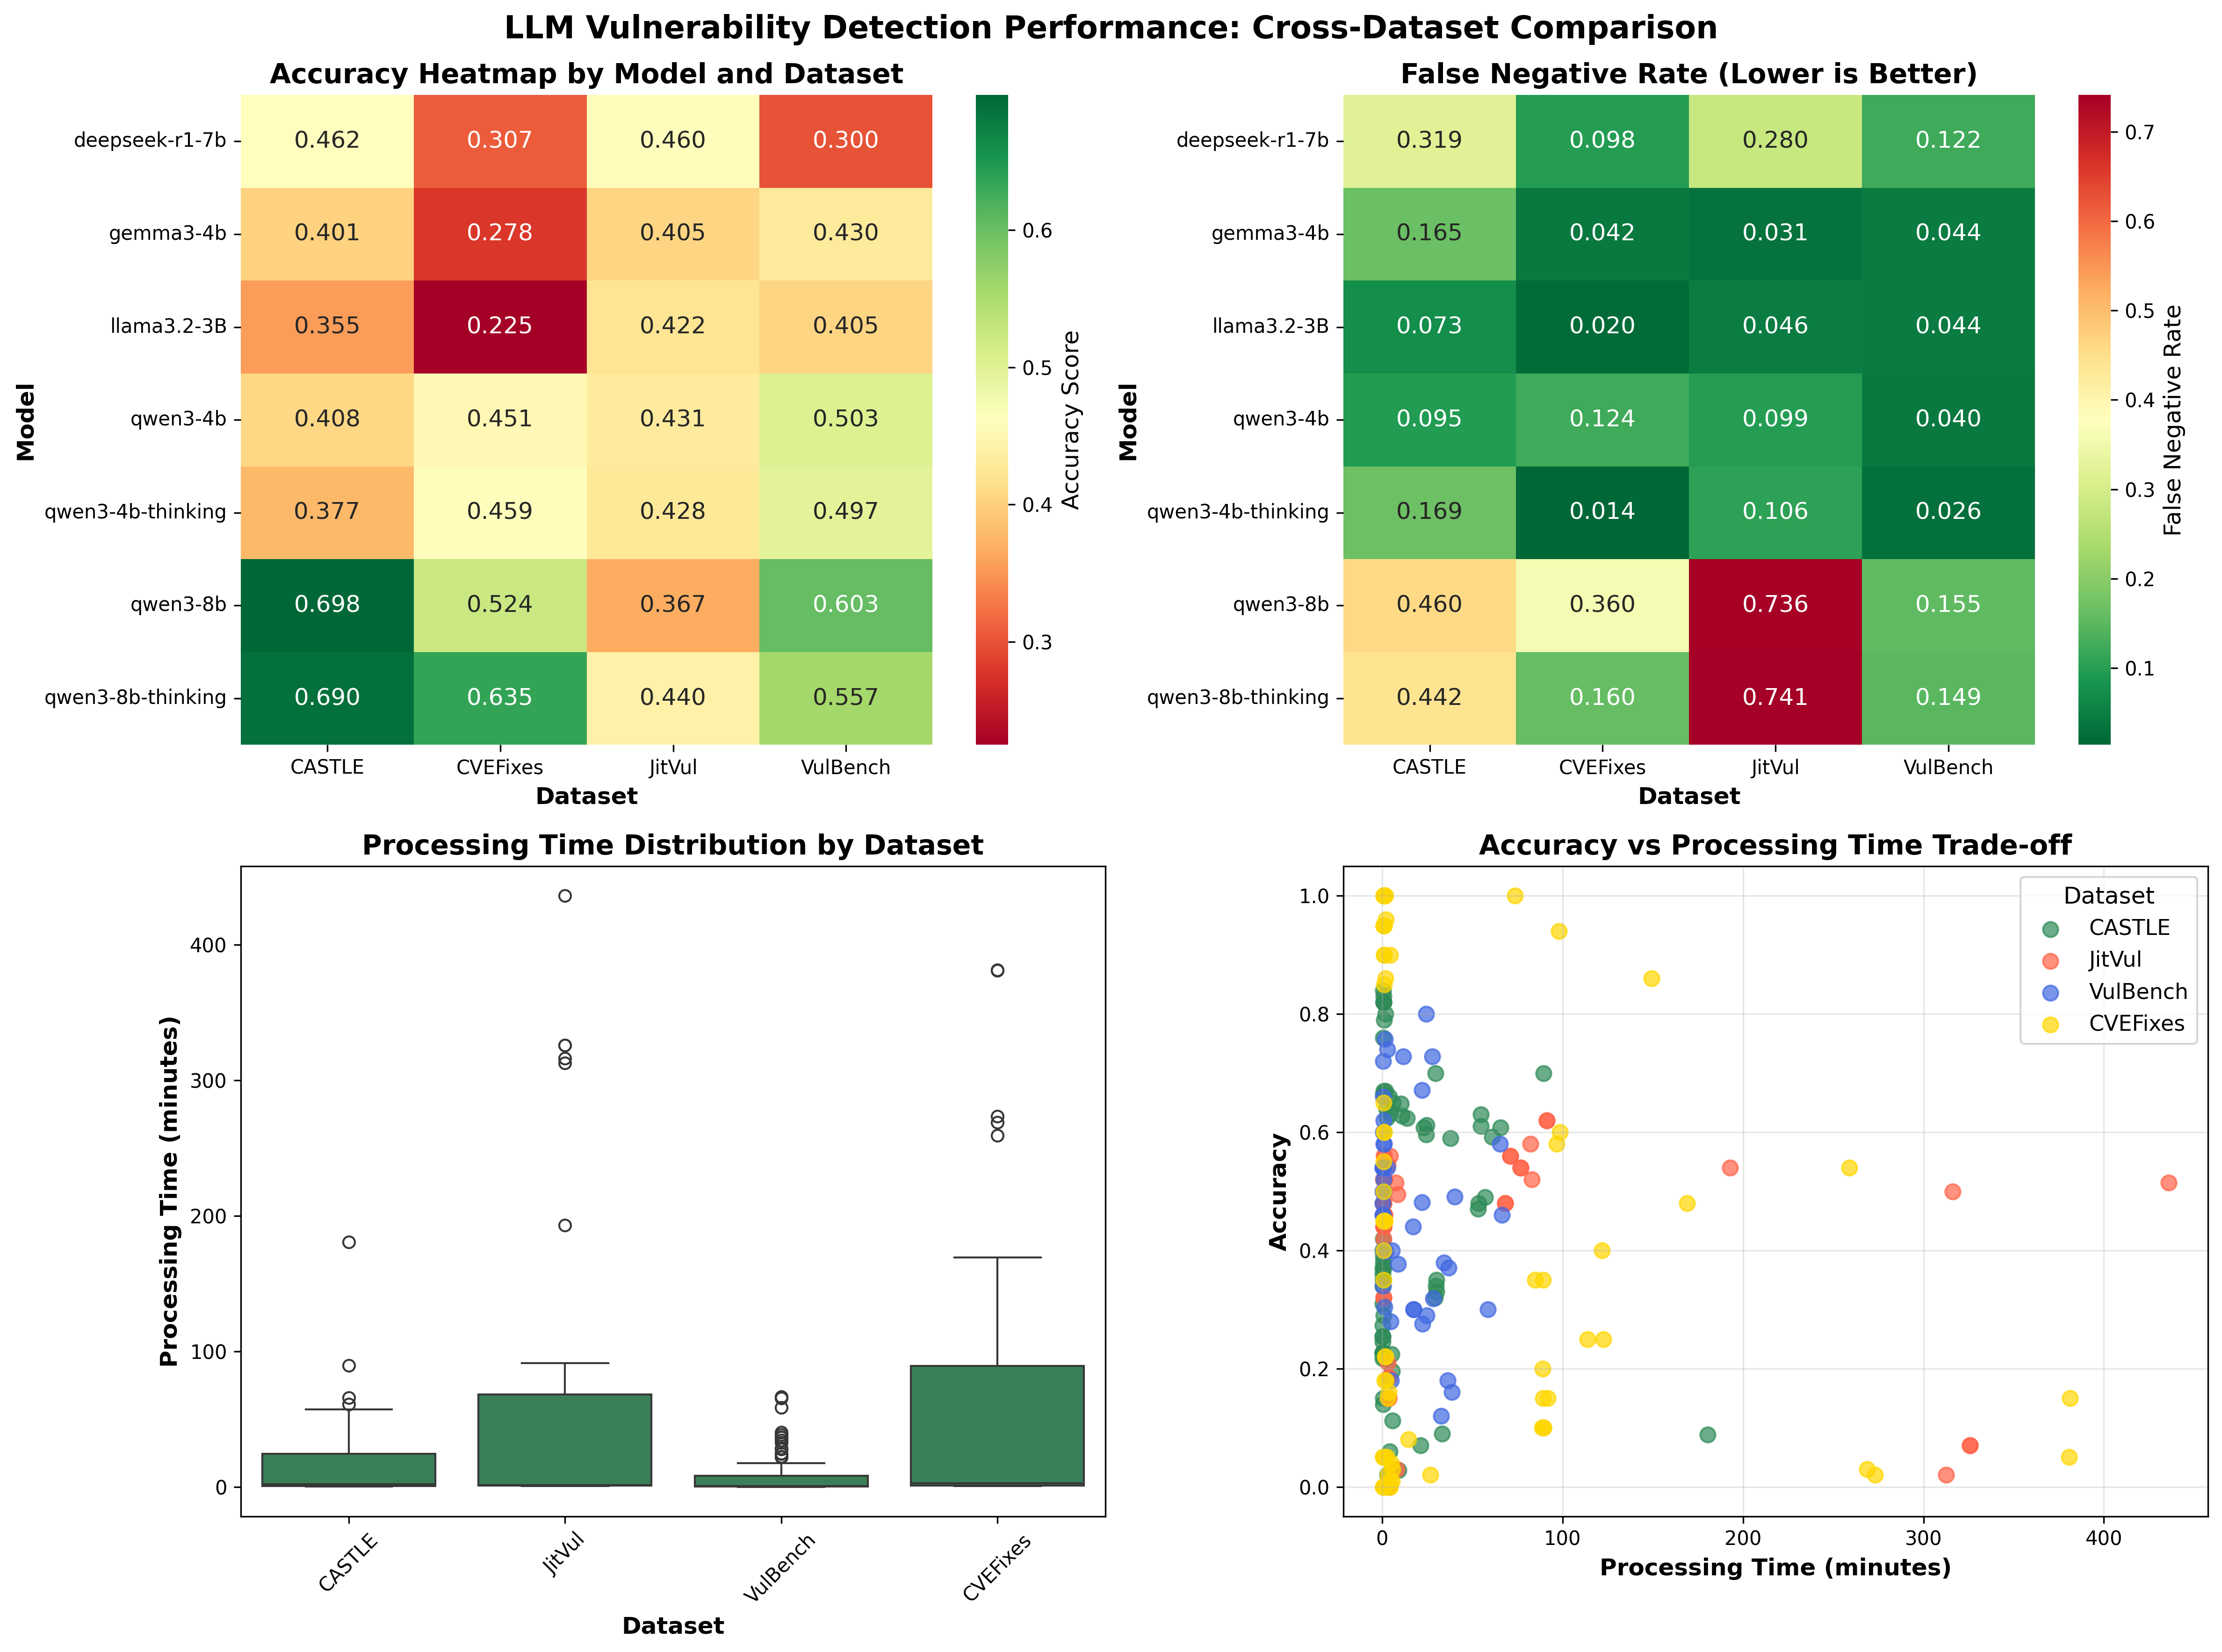


=== CROSS-DATASET PERFORMANCE SUMMARY ===
          accuracy_mean  accuracy_std  accuracy_min  accuracy_max  \
dataset                                                             
CASTLE           0.4445        0.2332          0.02          0.84   
CVEFixes         0.4113        0.3634          0.00          1.00   
JitVul           0.4230        0.1677          0.00          0.62   
VulBench         0.4686        0.1692          0.12          0.80   

          false_negative_rate_mean  false_negative_rate_std  \
dataset                                                       
CASTLE                      0.1836                   0.2059   
CVEFixes                    0.1169                   0.2779   
JitVul                      0.3582                   0.3924   
VulBench                    0.0770                   0.1647   

          false_negative_rate_min  false_negative_rate_max  time_minutes_mean  \
dataset                                                                         
C

In [5]:
# 1. COMPREHENSIVE PERFORMANCE COMPARISON ACROSS DATASETS

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('LLM Vulnerability Detection Performance: Cross-Dataset Comparison', fontsize=16, fontweight='bold')

# 1.1 Accuracy Comparison by Dataset and Model
ax1 = axes[0, 0]
accuracy_pivot = all_results_df.pivot_table(values='accuracy', index='model', columns='dataset', aggfunc='mean')
sns.heatmap(accuracy_pivot, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax1, cbar_kws={'label': 'Accuracy Score'})
ax1.set_title('Accuracy Heatmap by Model and Dataset', fontweight='bold')
ax1.set_xlabel('Dataset', fontweight='bold')
ax1.set_ylabel('Model', fontweight='bold')

# 1.2 False Negative Rate (Critical for Security)
ax2 = axes[0, 1]
fnr_pivot = all_results_df.pivot_table(values='false_negative_rate', index='model', columns='dataset', aggfunc='mean')
sns.heatmap(fnr_pivot, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax2, cbar_kws={'label': 'False Negative Rate'})
ax2.set_title('False Negative Rate (Lower is Better)', fontweight='bold')
ax2.set_xlabel('Dataset', fontweight='bold')
ax2.set_ylabel('Model', fontweight='bold')

# 1.3 Processing Time Comparison
ax3 = axes[1, 0]
# Convert time to minutes for better readability
all_results_df['time_minutes'] = all_results_df['total_time'] / 60
sns.boxplot(data=all_results_df, x='dataset', y='time_minutes', ax=ax3)
ax3.set_title('Processing Time Distribution by Dataset', fontweight='bold')
ax3.set_xlabel('Dataset', fontweight='bold')
ax3.set_ylabel('Processing Time (minutes)', fontweight='bold')
ax3.tick_params(axis='x', rotation=45)

# 1.4 Accuracy vs Time Efficiency
ax4 = axes[1, 1]
for dataset in all_results_df['dataset'].unique():
    data = all_results_df[all_results_df['dataset'] == dataset]
    ax4.scatter(data['time_minutes'], data['accuracy'], label=dataset, alpha=0.7, s=60)

ax4.set_xlabel('Processing Time (minutes)', fontweight='bold')
ax4.set_ylabel('Accuracy', fontweight='bold')
ax4.set_title('Accuracy vs Processing Time Trade-off', fontweight='bold')
ax4.legend(title='Dataset')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics table
print("\n=== CROSS-DATASET PERFORMANCE SUMMARY ===")
summary_stats = all_results_df.groupby('dataset').agg({
    'accuracy': ['mean', 'std', 'min', 'max'],
    'false_negative_rate': ['mean', 'std', 'min', 'max'],
    'time_minutes': ['mean', 'std', 'min', 'max']
}).round(4)

summary_stats.columns = ['_'.join(col).strip() for col in summary_stats.columns.values]
print(summary_stats)

=== TOP 10 MODELS BY OVERALL PERFORMANCE ===
Performance Score = 0.4×Accuracy + 0.4×(1-FNR) + 0.2×Efficiency
                   performance_score  accuracy  false_negative_rate  \
model                                                                 
qwen3-4b-thinking             0.7185    0.4405               0.0697   
qwen3-4b                      0.7020    0.4402               0.0848   
qwen3-8b-thinking             0.6417    0.5659               0.3755   
llama3.2-3B                   0.6054    0.3449               0.0503   
qwen3-8b                      0.5823    0.5179               0.4327   
gemma3-4b                     0.5295    0.3625               0.0674   
deepseek-r1-7b                0.4769    0.3847               0.1945   

                   accuracy_per_time  time_minutes  
model                                               
qwen3-4b-thinking             0.5410        1.4314  
qwen3-4b                      0.3942        3.0926  
qwen3-8b-thinking             0.5858   

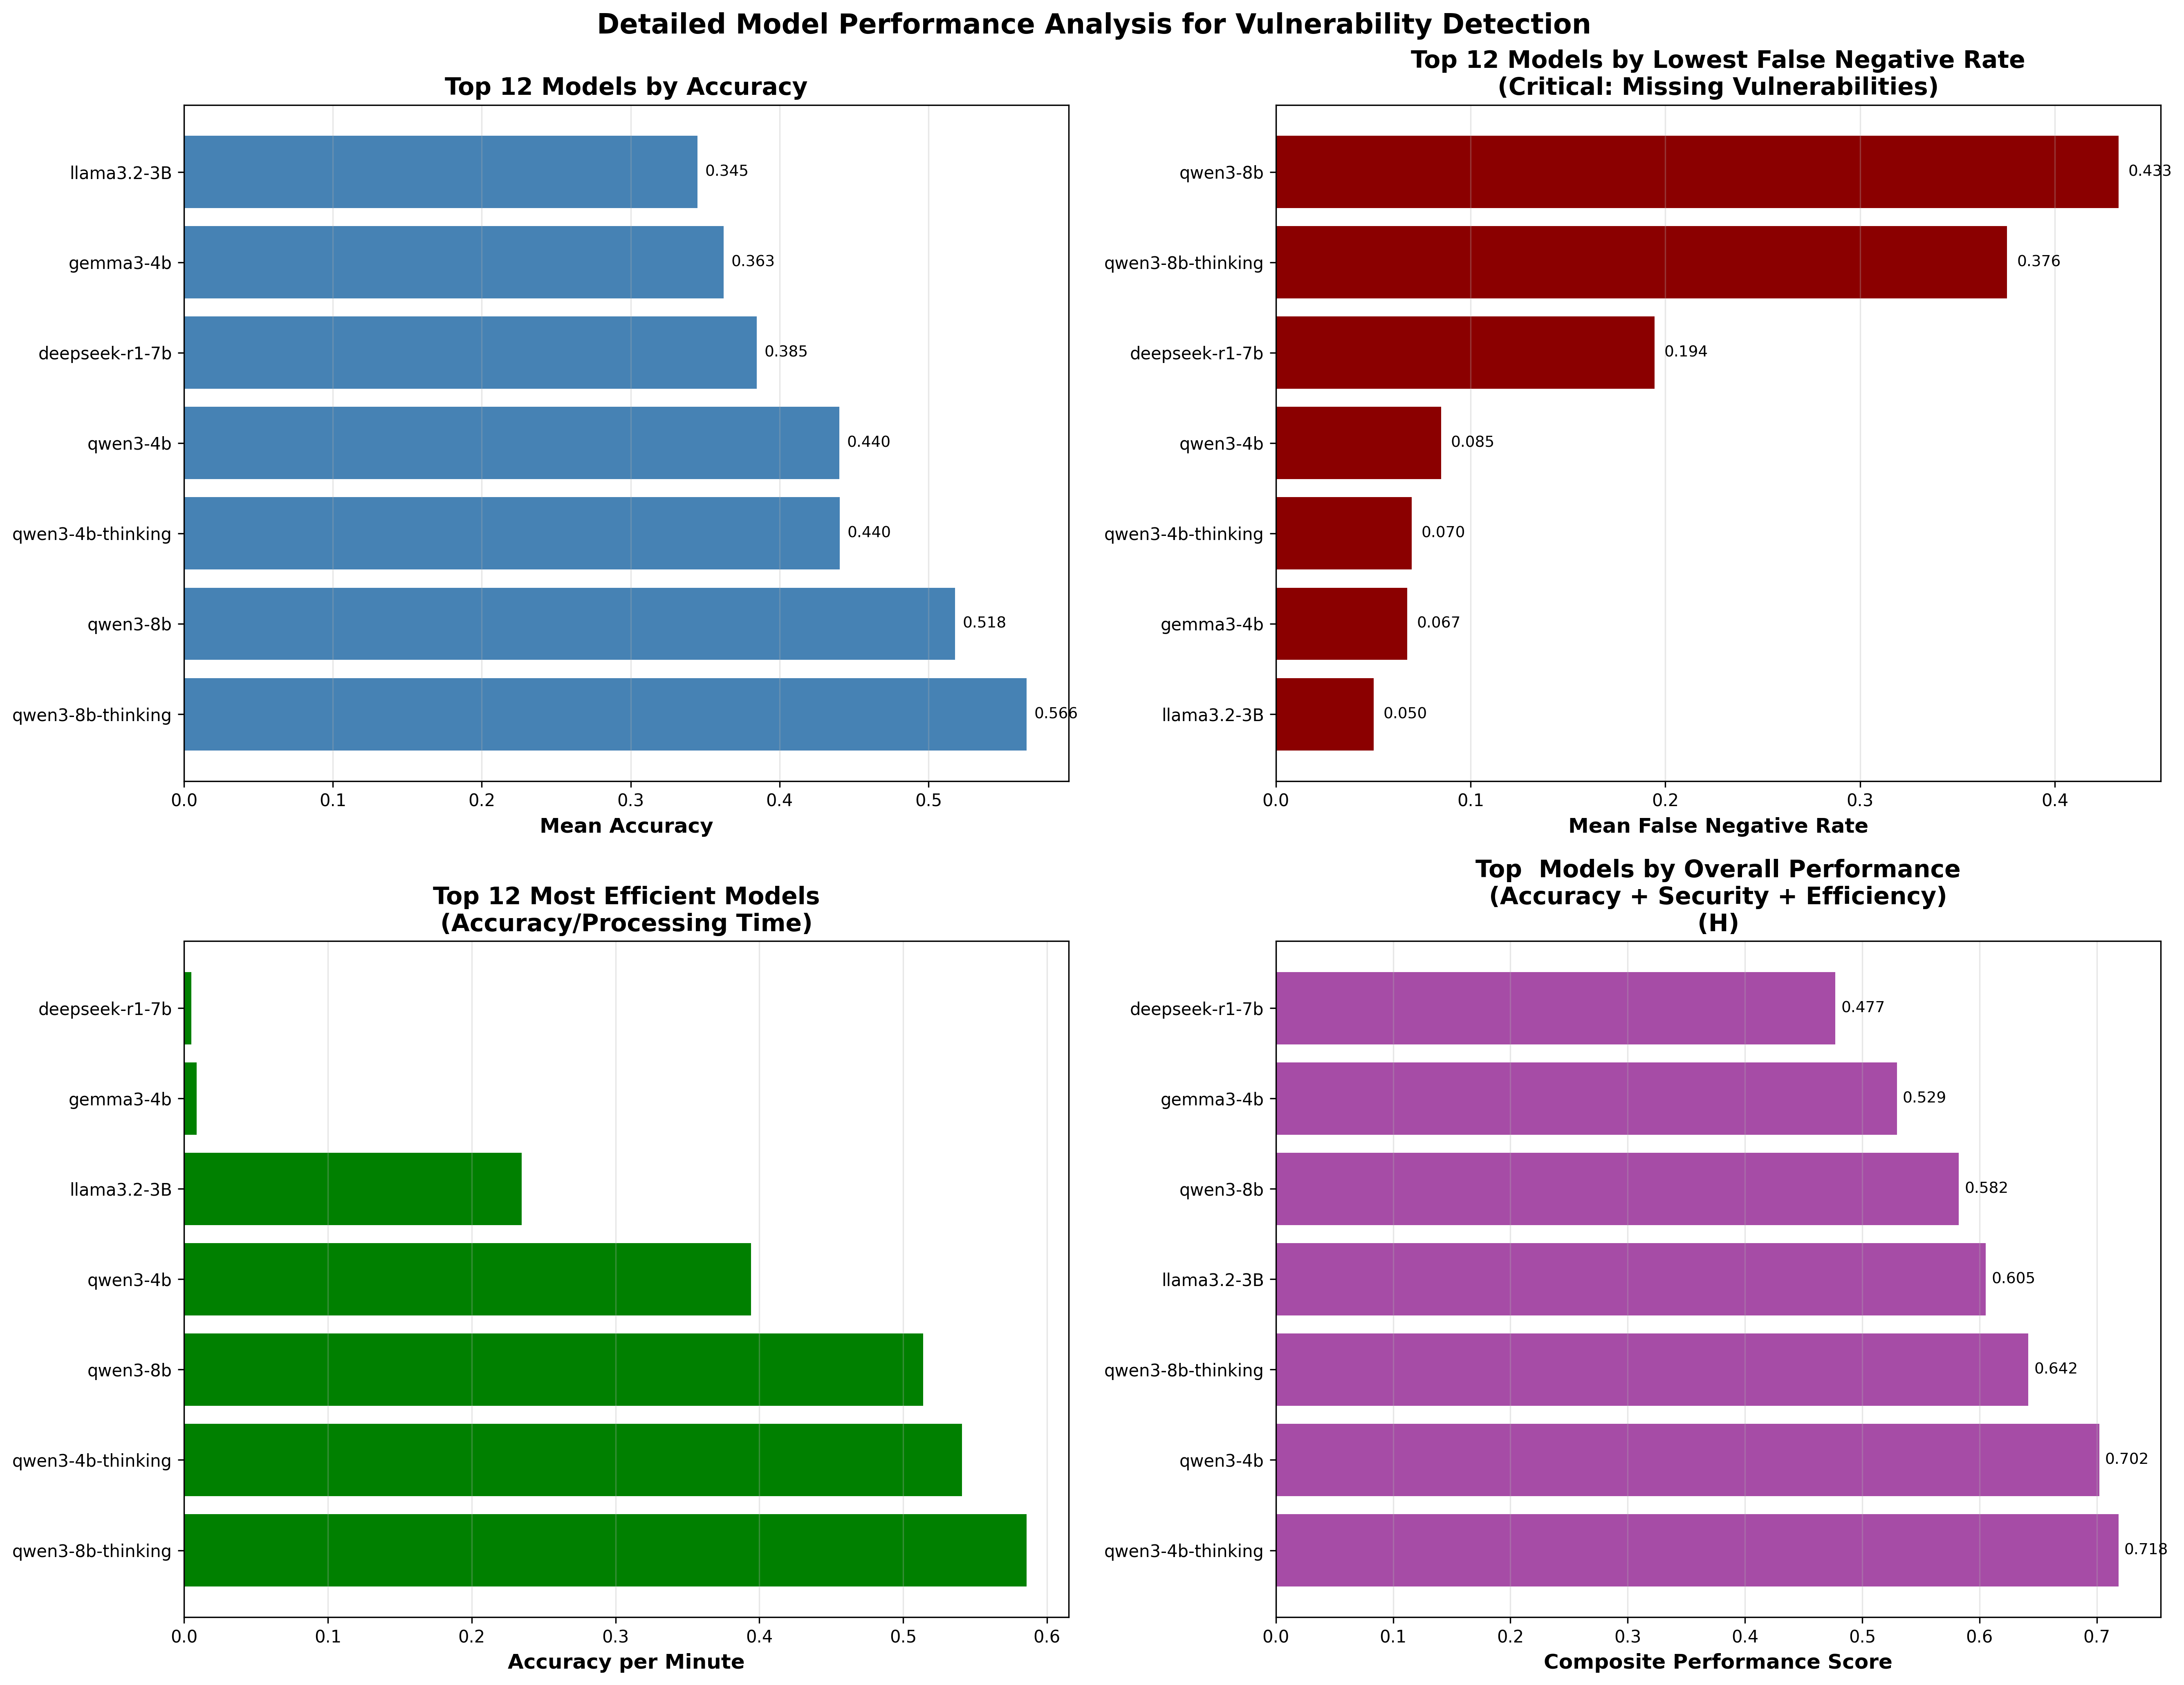

In [6]:
# 2. DETAILED MODEL PERFORMANCE ANALYSIS

# Calculate overall performance scores for ranking
def calculate_performance_score(row):
    """
    Calculate composite performance score considering:
    - Accuracy (40% weight)
    - False Negative Rate penalty (40% weight) - critical for security
    - Efficiency bonus (20% weight)
    """
    accuracy_score = row['accuracy'] * 0.4
    fnr_penalty = (1 - row['false_negative_rate']) * 0.4  # Lower FNR is better
    efficiency_score = min(row['accuracy_per_time'] / 0.1, 1.0) * 0.2  # Normalized efficiency
    return accuracy_score + fnr_penalty + efficiency_score

all_results_df['performance_score'] = all_results_df.apply(calculate_performance_score, axis=1)

# Model ranking by overall performance
model_rankings = all_results_df.groupby('model').agg({
    'performance_score': 'mean',
    'accuracy': 'mean',
    'false_negative_rate': 'mean',
    'accuracy_per_time': 'mean',
    'time_minutes': 'mean'
}).sort_values('performance_score', ascending=False)

print("=== TOP 10 MODELS BY OVERALL PERFORMANCE ===")
print("Performance Score = 0.4×Accuracy + 0.4×(1-FNR) + 0.2×Efficiency")
print(model_rankings.head(10).round(4))

# Visualization: Model Performance Comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Detailed Model Performance Analysis for Vulnerability Detection', fontsize=16, fontweight='bold')

# 2.1 Top Models by Accuracy
ax1 = axes[0, 0]
top_accuracy = all_results_df.groupby('model')['accuracy'].mean().sort_values(ascending=False).head(12)
bars1 = ax1.barh(range(len(top_accuracy)), top_accuracy.values, color='steelblue')
ax1.set_yticks(range(len(top_accuracy)))
ax1.set_yticklabels(top_accuracy.index, fontsize=10)
ax1.set_xlabel('Mean Accuracy', fontweight='bold')
ax1.set_title('Top 12 Models by Accuracy', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(width + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}', ha='left', va='center', fontsize=9)

# 2.2 False Negative Rate Analysis (Critical for Security)
ax2 = axes[0, 1]
fnr_by_model = all_results_df.groupby('model')['false_negative_rate'].mean().sort_values().head(12)
bars2 = ax2.barh(range(len(fnr_by_model)), fnr_by_model.values, color='darkred')
ax2.set_yticks(range(len(fnr_by_model)))
ax2.set_yticklabels(fnr_by_model.index, fontsize=10)
ax2.set_xlabel('Mean False Negative Rate', fontweight='bold')
ax2.set_title('Top 12 Models by Lowest False Negative Rate\n(Critical: Missing Vulnerabilities)', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars2):
    width = bar.get_width()
    ax2.text(width + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}', ha='left', va='center', fontsize=9)

# 2.3 Efficiency Analysis (Accuracy per Time)
ax3 = axes[1, 0]
efficiency_data = all_results_df.groupby('model').agg({
    'accuracy_per_time': 'mean',
    'accuracy': 'mean',
    'time_minutes': 'mean'
}).sort_values('accuracy_per_time', ascending=False).head(12)

bars3 = ax3.barh(range(len(efficiency_data)), efficiency_data['accuracy_per_time'].values, color='green')
ax3.set_yticks(range(len(efficiency_data)))
ax3.set_yticklabels(efficiency_data.index, fontsize=10)
ax3.set_xlabel('Accuracy per Minute', fontweight='bold')
ax3.set_title('Top 12 Most Efficient Models\n(Accuracy/Processing Time)', fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# 2.4 Overall Performance Score
ax4 = axes[1, 1]
top_performance = model_rankings.head(12)
bars4 = ax4.barh(range(len(top_performance)), top_performance['performance_score'].values, 
                 color='purple', alpha=0.7)
ax4.set_yticks(range(len(top_performance)))
ax4.set_yticklabels(top_performance.index, fontsize=10)
ax4.set_xlabel('Composite Performance Score', fontweight='bold')
ax4.set_title('Top  Models by Overall Performance\n(Accuracy + Security + Efficiency)\n(H)', fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars4):
    width = bar.get_width()
    ax4.text(width + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

=== Топ-10 моделей по общей производительности ===
Оценка производительности = 0.4×Точность + 0.4×(1 - Уровень ложноотрицательных) + 0.2×Эффективность
                   performance_score  accuracy  false_negative_rate  \
model                                                                 
qwen3-4b-thinking             0.7185    0.4405               0.0697   
qwen3-4b                      0.7020    0.4402               0.0848   
qwen3-8b-thinking             0.6417    0.5659               0.3755   
llama3.2-3B                   0.6054    0.3449               0.0503   
qwen3-8b                      0.5823    0.5179               0.4327   
gemma3-4b                     0.5295    0.3625               0.0674   
deepseek-r1-7b                0.4769    0.3847               0.1945   

                   accuracy_per_time  time_minutes  
model                                               
qwen3-4b-thinking             0.5410        1.4314  
qwen3-4b                      0.3942        3.0926

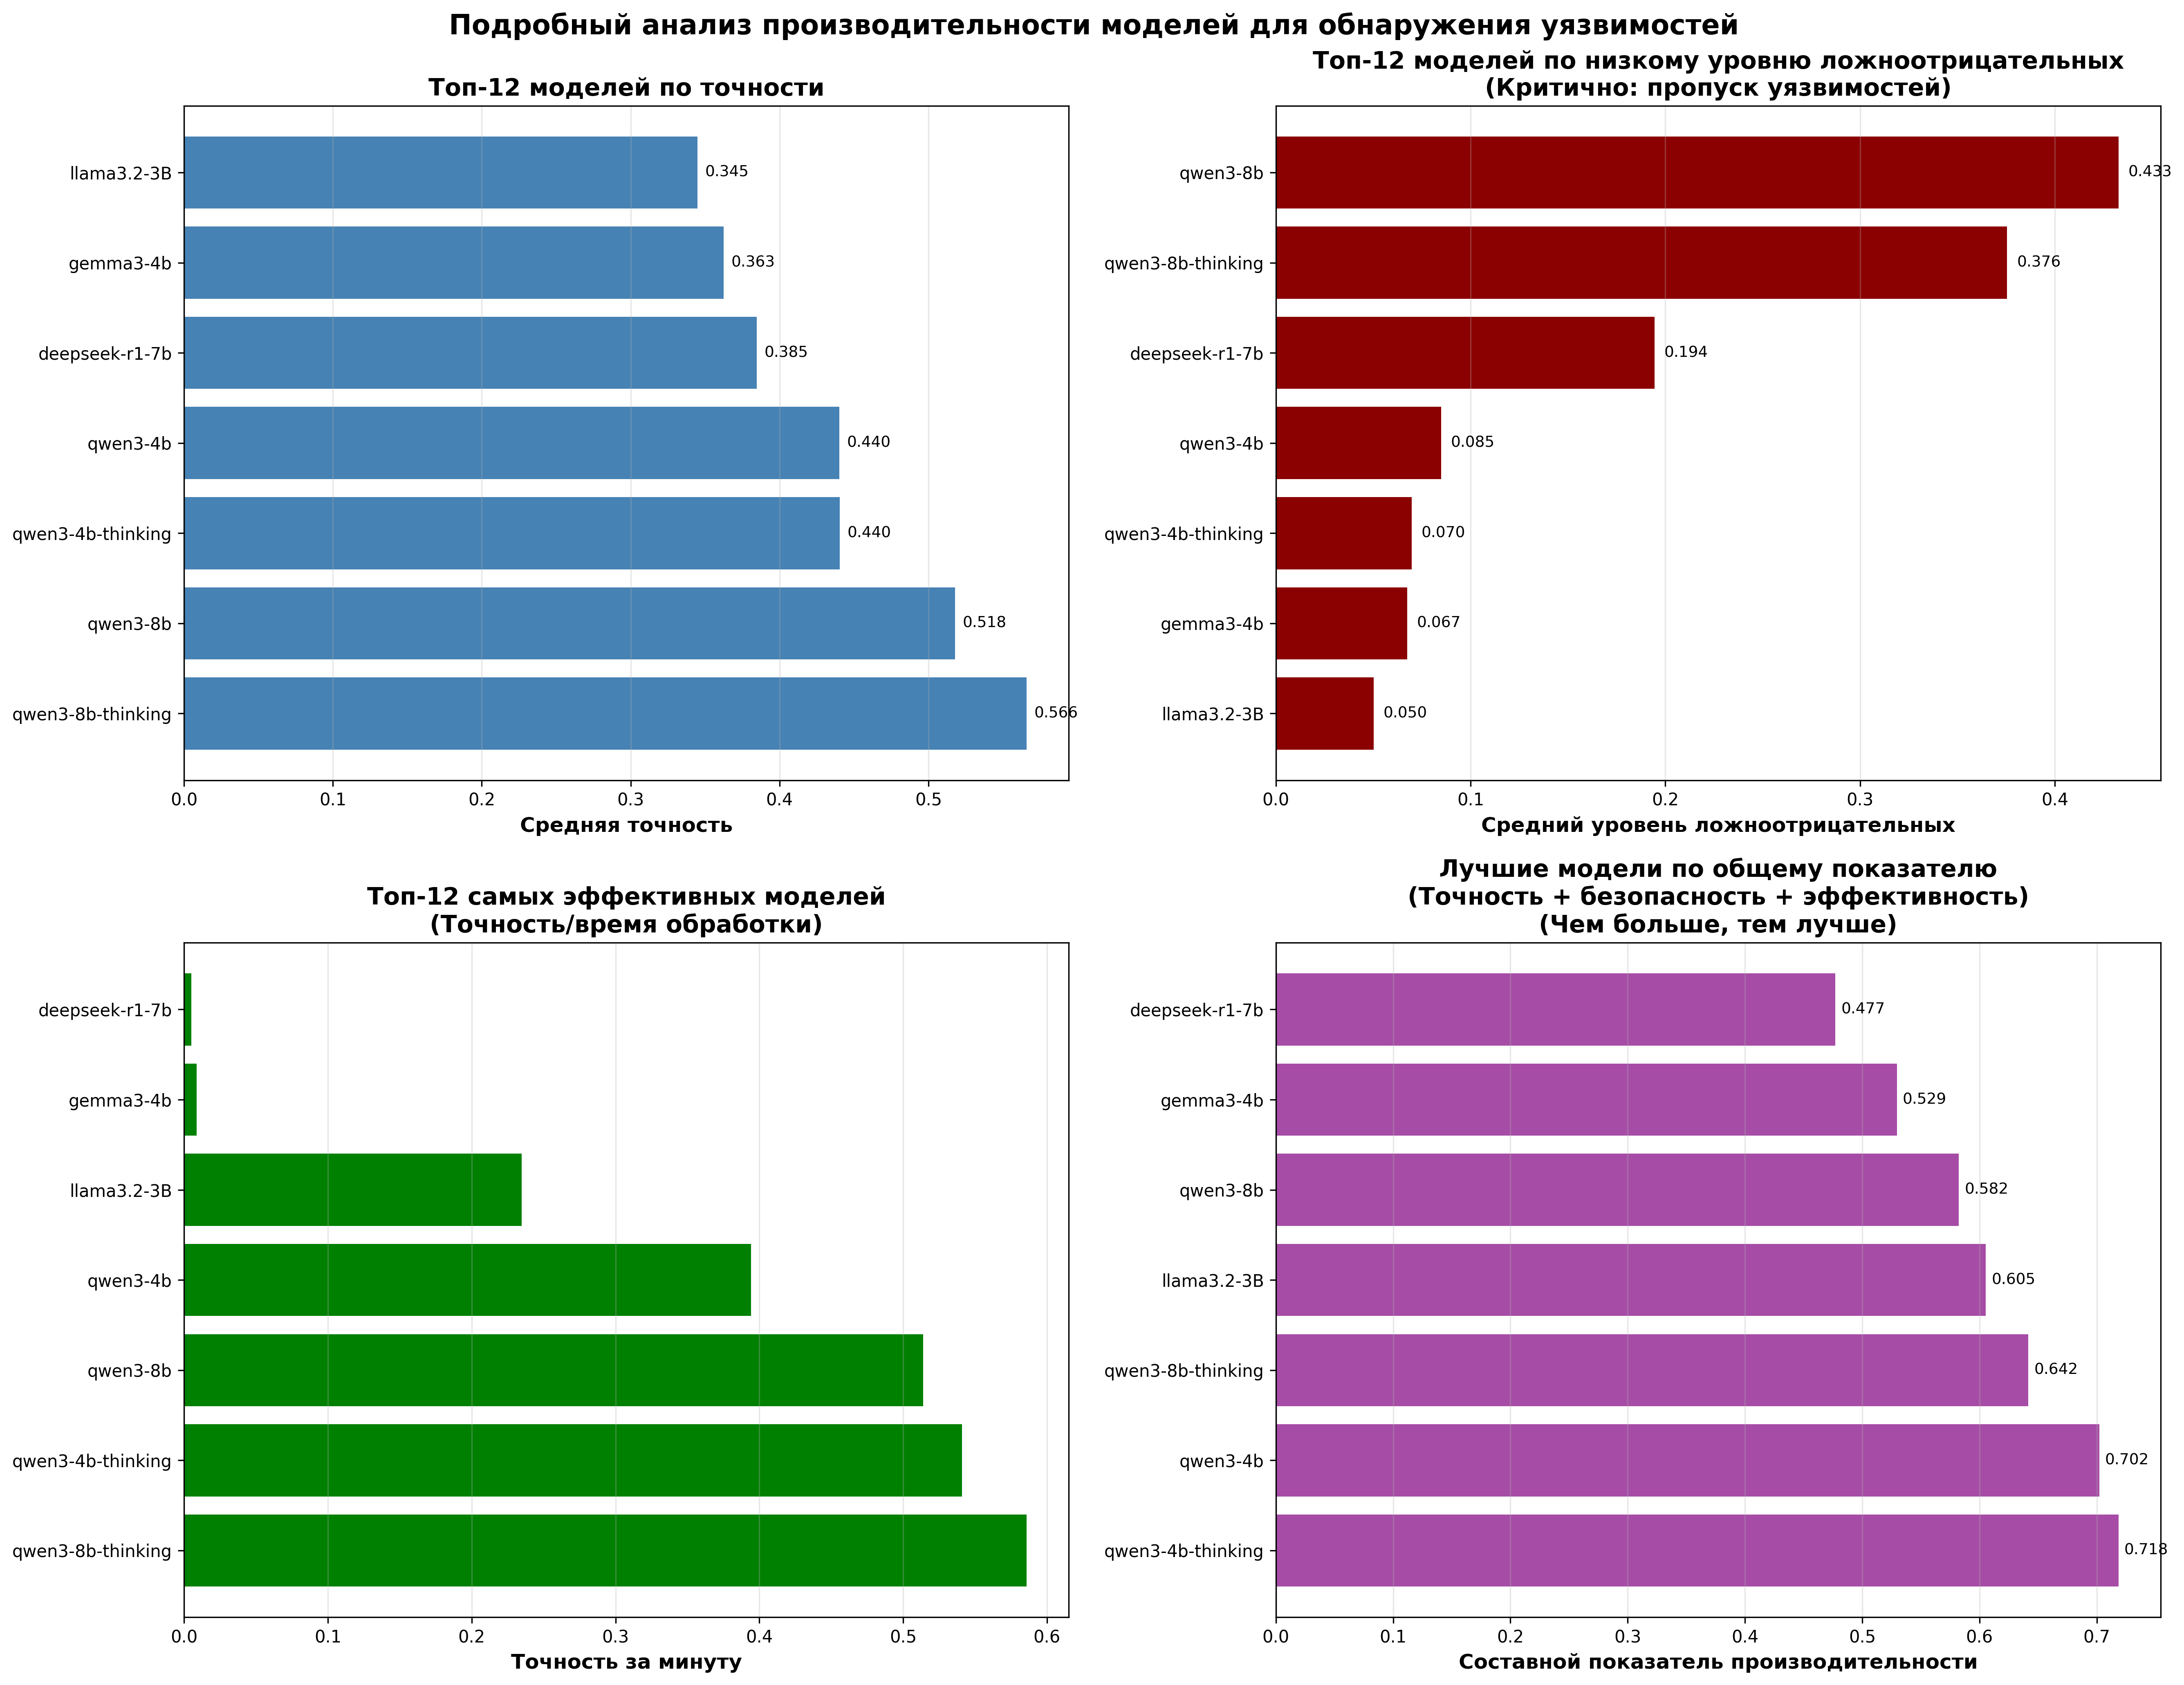

In [7]:
# 2. DETAILED MODEL PERFORMANCE ANALYSIS

# Calculate overall performance scores for ranking
def calculate_performance_score(row):
    """
    Calculate composite performance score considering:
    - Accuracy (40% weight)
    - False Negative Rate penalty (40% weight) - critical for security
    - Efficiency bonus (20% weight)
    """
    accuracy_score = row['accuracy'] * 0.4
    fnr_penalty = (1 - row['false_negative_rate']) * 0.4  # Lower FNR is better
    efficiency_score = min(row['accuracy_per_time'] / 0.1, 1.0) * 0.2  # Normalized efficiency
    return accuracy_score + fnr_penalty + efficiency_score

all_results_df['performance_score'] = all_results_df.apply(calculate_performance_score, axis=1)

# Model ranking by overall performance
model_rankings = all_results_df.groupby('model').agg({
    'performance_score': 'mean',
    'accuracy': 'mean',
    'false_negative_rate': 'mean',
    'accuracy_per_time': 'mean',
    'time_minutes': 'mean'
}).sort_values('performance_score', ascending=False)

print("=== Топ-10 моделей по общей производительности ===")
print("Оценка производительности = 0.4×Точность + 0.4×(1 - Уровень ложноотрицательных) + 0.2×Эффективность")
print(model_rankings.head(10).round(4))

# Visualization: Model Performance Comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Подробный анализ производительности моделей для обнаружения уязвимостей',
             fontsize=16, fontweight='bold')

# 2.1 Топ-12 моделей по точности
ax1 = axes[0, 0]
top_accuracy = all_results_df.groupby('model')['accuracy'].mean().sort_values(ascending=False).head(12)
bars1 = ax1.barh(range(len(top_accuracy)), top_accuracy.values, color='steelblue')
ax1.set_yticks(range(len(top_accuracy)))
ax1.set_yticklabels(top_accuracy.index, fontsize=10)
ax1.set_xlabel('Средняя точность', fontweight='bold')
ax1.set_title('Топ-12 моделей по точности', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(width + 0.005, bar.get_y() + bar.get_height()/2,
             f'{width:.3f}', ha='left', va='center', fontsize=9)

# 2.2 Анализ уровня ложноотрицательных (критично для безопасности)
ax2 = axes[0, 1]
fnr_by_model = all_results_df.groupby('model')['false_negative_rate'].mean().sort_values().head(12)
bars2 = ax2.barh(range(len(fnr_by_model)), fnr_by_model.values, color='darkred')
ax2.set_yticks(range(len(fnr_by_model)))
ax2.set_yticklabels(fnr_by_model.index, fontsize=10)
ax2.set_xlabel('Средний уровень ложноотрицательных', fontweight='bold')
ax2.set_title('Топ-12 моделей по низкому уровню ложноотрицательных\n(Критично: пропуск уязвимостей)',
              fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

for i, bar in enumerate(bars2):
    width = bar.get_width()
    ax2.text(width + 0.005, bar.get_y() + bar.get_height()/2,
             f'{width:.3f}', ha='left', va='center', fontsize=9)

# 2.3 Анализ эффективности (точность за время)
ax3 = axes[1, 0]
efficiency_data = all_results_df.groupby('model').agg({
    'accuracy_per_time': 'mean',
    'accuracy': 'mean',
    'time_minutes': 'mean'
}).sort_values('accuracy_per_time', ascending=False).head(12)
bars3 = ax3.barh(range(len(efficiency_data)), efficiency_data['accuracy_per_time'].values, color='green')
ax3.set_yticks(range(len(efficiency_data)))
ax3.set_yticklabels(efficiency_data.index, fontsize=10)
ax3.set_xlabel('Точность за минуту', fontweight='bold')
ax3.set_title('Топ-12 самых эффективных моделей\n(Точность/время обработки)', fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# 2.4 Общий показатель производительности
ax4 = axes[1, 1]
top_performance = model_rankings.head(12)
bars4 = ax4.barh(range(len(top_performance)), top_performance['performance_score'].values,
                 color='purple', alpha=0.7)
ax4.set_yticks(range(len(top_performance)))
ax4.set_yticklabels(top_performance.index, fontsize=10)
ax4.set_xlabel('Составной показатель производительности', fontweight='bold')
ax4.set_title('Лучшие модели по общему показателю\n(Точность + безопасность + эффективность)\n(Чем больше, тем лучше)',
              fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

for i, bar in enumerate(bars4):
    width = bar.get_width()
    ax4.text(width + 0.005, bar.get_y() + bar.get_height()/2,
             f'{width:.3f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()


=== FALSE NEGATIVE ANALYSIS: CRITICAL FOR VULNERABILITY DETECTION ===
False negatives represent MISSED vulnerabilities - extremely dangerous in security contexts



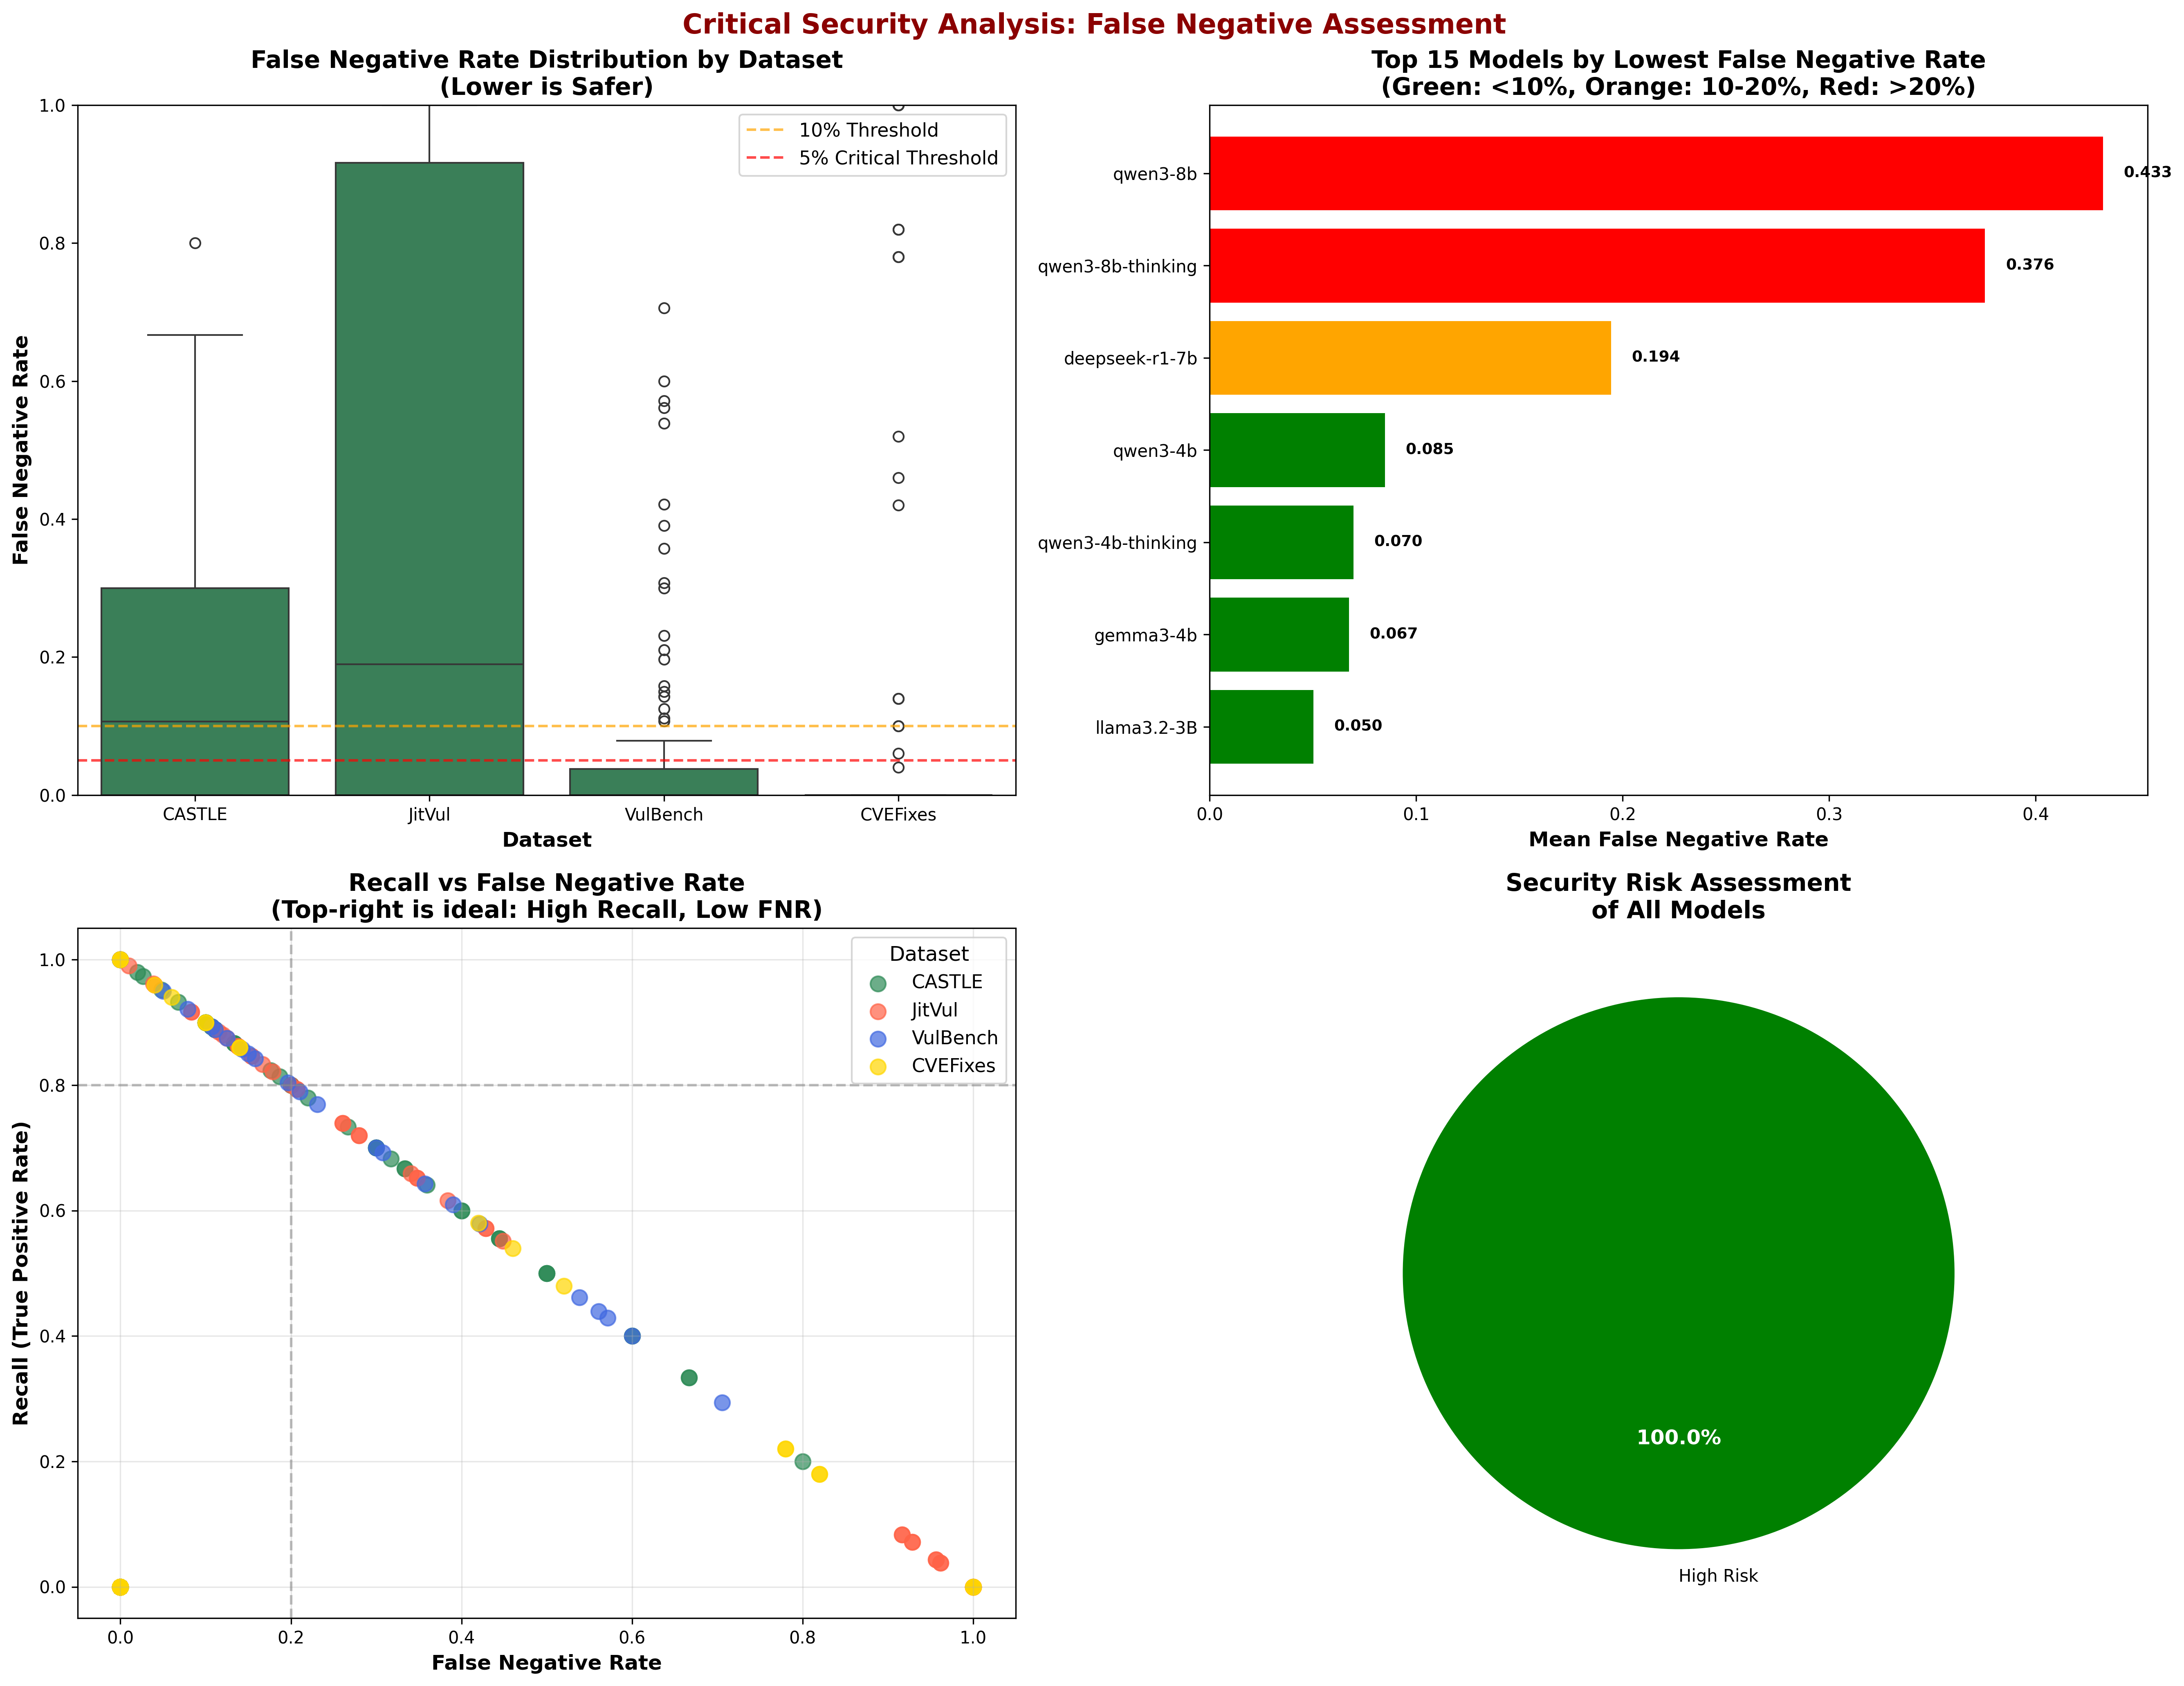


=== CRITICAL SECURITY FINDINGS ===
Models with <10% False Negative Rate (Recommended): 7
Top 5 Safest Models (Lowest FNR):
1. llama3.2-3B: 0.050 FNR
2. gemma3-4b: 0.067 FNR
3. qwen3-4b-thinking: 0.070 FNR
4. qwen3-4b: 0.085 FNR
5. deepseek-r1-7b: 0.194 FNR

High-Risk Models (>30% FNR): 7
⚠️  These models miss >30% of vulnerabilities - NOT recommended for production


In [7]:
# 3. CRITICAL FALSE NEGATIVE ANALYSIS (SECURITY FOCUS)

print("=== FALSE NEGATIVE ANALYSIS: CRITICAL FOR VULNERABILITY DETECTION ===")
print("False negatives represent MISSED vulnerabilities - extremely dangerous in security contexts")
print()

# Calculate detailed FN statistics
fn_analysis = all_results_df.groupby(['dataset', 'model']).agg({
    'false_negatives': 'mean',
    'false_negative_rate': 'mean',
    'true_positives': 'mean',
    'recall': 'mean'
}).round(4)

# Critical security metrics visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Critical Security Analysis: False Negative Assessment', fontsize=16, fontweight='bold', color='darkred')

# 3.1 False Negative Rate by Dataset and Model
ax1 = axes[0, 0]
fnr_data = []
dataset_labels = []
model_labels = []

for dataset in all_results_df['dataset'].unique():
    dataset_data = all_results_df[all_results_df['dataset'] == dataset]
    fnr_by_model = dataset_data.groupby('model')['false_negative_rate'].mean().sort_values()
    
    for model, fnr in fnr_by_model.items():
        fnr_data.append(fnr)
        dataset_labels.append(dataset)
        model_labels.append(model)

# Create a more detailed FNR analysis
fnr_df = pd.DataFrame({
    'Dataset': dataset_labels,
    'Model': model_labels,
    'FNR': fnr_data
})

# Box plot showing FNR distribution by dataset
sns.boxplot(data=all_results_df, x='dataset', y='false_negative_rate', ax=ax1)
ax1.set_title('False Negative Rate Distribution by Dataset\n(Lower is Safer)', fontweight='bold')
ax1.set_xlabel('Dataset', fontweight='bold')
ax1.set_ylabel('False Negative Rate', fontweight='bold')
ax1.set_ylim(0, 1)

# Add horizontal lines for critical thresholds
ax1.axhline(y=0.1, color='orange', linestyle='--', alpha=0.7, label='10% Threshold')
ax1.axhline(y=0.05, color='red', linestyle='--', alpha=0.7, label='5% Critical Threshold')
ax1.legend()

# 3.2 Models with Lowest False Negative Rates
ax2 = axes[0, 1]
best_fnr_models = all_results_df.groupby('model')['false_negative_rate'].mean().sort_values().head(15)
bars = ax2.barh(range(len(best_fnr_models)), best_fnr_models.values, 
                color=['green' if x < 0.1 else 'orange' if x < 0.2 else 'red' for x in best_fnr_models.values])
ax2.set_yticks(range(len(best_fnr_models)))
ax2.set_yticklabels(best_fnr_models.index, fontsize=10)
ax2.set_xlabel('Mean False Negative Rate', fontweight='bold')
ax2.set_title('Top 15 Models by Lowest False Negative Rate\n(Green: <10%, Orange: 10-20%, Red: >20%)', fontweight='bold')

# Add value labels
for i, (bar, value) in enumerate(zip(bars, best_fnr_models.values)):
    ax2.text(value + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{value:.3f}', ha='left', va='center', fontsize=9, fontweight='bold')

# 3.3 Recall vs False Negative Rate Scatter
ax3 = axes[1, 0]
for dataset in all_results_df['dataset'].unique():
    data = all_results_df[all_results_df['dataset'] == dataset]
    ax3.scatter(data['false_negative_rate'], data['recall'], label=dataset, alpha=0.7, s=80)

ax3.set_xlabel('False Negative Rate', fontweight='bold')
ax3.set_ylabel('Recall (True Positive Rate)', fontweight='bold')
ax3.set_title('Recall vs False Negative Rate\n(Top-right is ideal: High Recall, Low FNR)', fontweight='bold')
ax3.legend(title='Dataset')
ax3.grid(True, alpha=0.3)

# Add quadrant lines
ax3.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5)
ax3.axvline(x=0.2, color='gray', linestyle='--', alpha=0.5)

# 3.4 Security Risk Assessment Matrix
ax4 = axes[1, 1]
risk_matrix = all_results_df.groupby('model').agg({
    'false_negative_rate': 'mean',
    'accuracy': 'mean'
}).round(3)

# Create risk categories
def assess_risk(row):
    if row['false_negative_rate'] < 0.1 and row['accuracy'] > 0.8:
        return 'Low Risk'
    elif row['false_negative_rate'] < 0.2 and row['accuracy'] > 0.6:
        return 'Medium Risk'
    else:
        return 'High Risk'

risk_matrix['risk_category'] = risk_matrix.apply(assess_risk, axis=1)
risk_counts = risk_matrix['risk_category'].value_counts()

colors_risk = ['green', 'orange', 'red']
wedges, texts, autotexts = ax4.pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%', 
                                   colors=colors_risk, startangle=90)
ax4.set_title('Security Risk Assessment\nof All Models', fontweight='bold')

# Make percentage text bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

plt.tight_layout()
plt.show()

# Print critical findings
print("\n=== CRITICAL SECURITY FINDINGS ===")
critical_models = all_results_df[all_results_df['false_negative_rate'] < 0.1]['model'].unique()
print(f"Models with <10% False Negative Rate (Recommended): {len(critical_models)}")
print("Top 5 Safest Models (Lowest FNR):")
for i, (model, fnr) in enumerate(best_fnr_models.head().items(), 1):
    print(f"{i}. {model}: {fnr:.3f} FNR")

high_risk_models = all_results_df[all_results_df['false_negative_rate'] > 0.3]['model'].unique()
print(f"\nHigh-Risk Models (>30% FNR): {len(high_risk_models)}")
if len(high_risk_models) > 0:
    print("⚠️  These models miss >30% of vulnerabilities - NOT recommended for production")

=== OPTIMAL MODEL SELECTION FOR PRACTICAL DEPLOYMENT ===
Balancing accuracy, security (low FNR), and computational efficiency



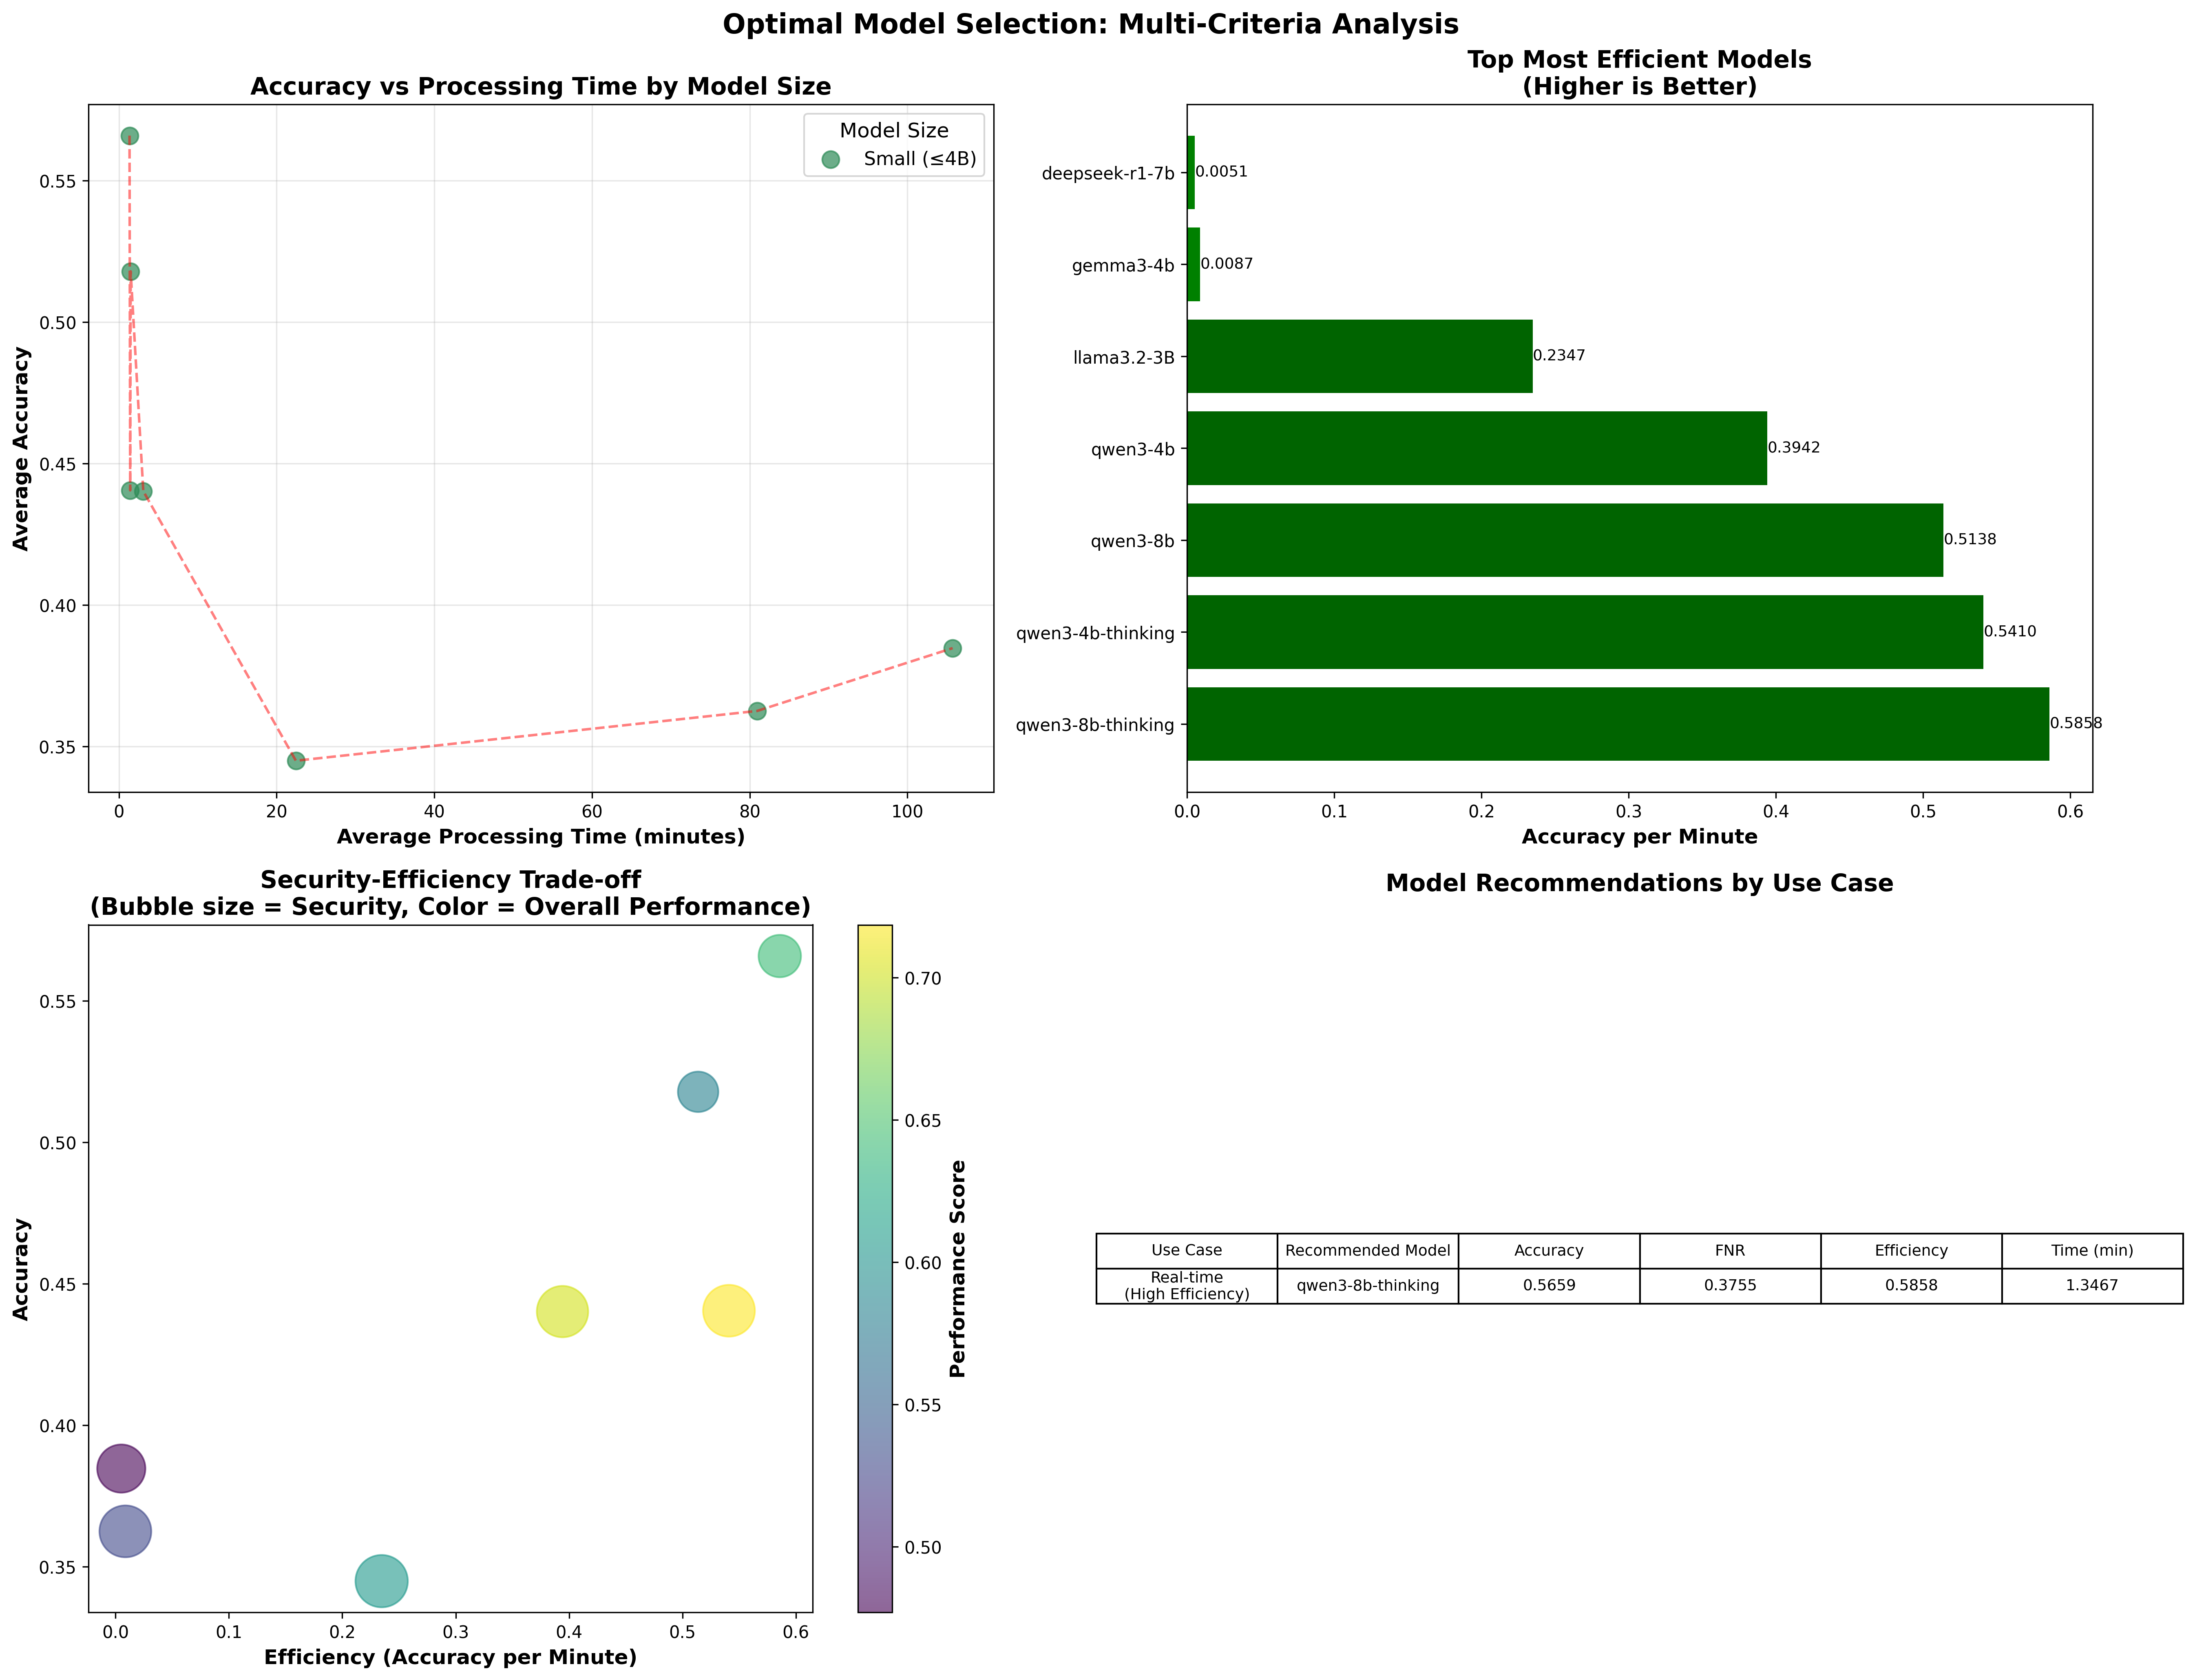


=== DETAILED MODEL RECOMMENDATIONS ===

🔴 PRODUCTION DEPLOYMENT (Security-First):
   ⚠️  No models meet strict production criteria

🔵 RESEARCH & DEVELOPMENT (Accuracy-First):
1. qwen3-8b-thinking
   ├─ Accuracy: 0.566
   ├─ False Negative Rate: 0.376
   └─ Avg Time: 1.3 minutes
2. qwen3-8b
   ├─ Accuracy: 0.518
   ├─ False Negative Rate: 0.433
   └─ Avg Time: 1.5 minutes
3. qwen3-4b-thinking
   ├─ Accuracy: 0.441
   ├─ False Negative Rate: 0.070
   └─ Avg Time: 1.4 minutes

🟢 REAL-TIME APPLICATIONS (Efficiency-First):
1. qwen3-8b-thinking
   ├─ Efficiency: 0.5858 accuracy/minute
   ├─ Accuracy: 0.566
   └─ Avg Time: 1.3 minutes
2. qwen3-4b-thinking
   ├─ Efficiency: 0.5410 accuracy/minute
   ├─ Accuracy: 0.441
   └─ Avg Time: 1.4 minutes
3. qwen3-8b
   ├─ Efficiency: 0.5138 accuracy/minute
   ├─ Accuracy: 0.518
   └─ Avg Time: 1.5 minutes


In [17]:
# 4. OPTIMAL MODEL SELECTION: ACCURACY/TIME TRADE-OFF ANALYSIS

print("=== OPTIMAL MODEL SELECTION FOR PRACTICAL DEPLOYMENT ===")
print("Balancing accuracy, security (low FNR), and computational efficiency")
print()

# Calculate comprehensive efficiency metrics
efficiency_metrics = all_results_df.groupby('model').agg({
    'accuracy': 'mean',
    'false_negative_rate': 'mean',
    'time_minutes': 'mean',
    'accuracy_per_time': 'mean',
    'performance_score': 'mean'
}).round(4)

# Add model size information for analysis
efficiency_metrics['model_size'] = efficiency_metrics.index.map(
    lambda x: all_results_df[all_results_df['model'] == x]['model_size'].iloc[0]
)

# Create Pareto frontier analysis
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Optimal Model Selection: Multi-Criteria Analysis', fontsize=16, fontweight='bold')

# 4.1 Accuracy vs Time Efficiency with Size Categories
ax1 = axes[0, 0]
for size_cat in efficiency_metrics['model_size'].unique():
    data = efficiency_metrics[efficiency_metrics['model_size'] == size_cat]
    ax1.scatter(data['time_minutes'], data['accuracy'], 
               label=size_cat, alpha=0.7, s=100)

ax1.set_xlabel('Average Processing Time (minutes)', fontweight='bold')
ax1.set_ylabel('Average Accuracy', fontweight='bold')
ax1.set_title('Accuracy vs Processing Time by Model Size', fontweight='bold')
ax1.legend(title='Model Size')
ax1.grid(True, alpha=0.3)

# Add Pareto frontier line
pareto_data = efficiency_metrics.copy()
pareto_data = pareto_data.sort_values('time_minutes')
ax1.plot(pareto_data['time_minutes'], pareto_data['accuracy'], 'r--', alpha=0.5, label='Trend')

# 4.2 Efficiency Ranking (Accuracy per Minute)
ax2 = axes[0, 1]
top_efficient = efficiency_metrics.sort_values('accuracy_per_time', ascending=False).head(15)
bars = ax2.barh(range(len(top_efficient)), top_efficient['accuracy_per_time'], 
                color=['darkgreen' if x > 0.01 else 'green' if x > 0.005 else 'orange' 
                       for x in top_efficient['accuracy_per_time']])
ax2.set_yticks(range(len(top_efficient)))
ax2.set_yticklabels(top_efficient.index, fontsize=10)
ax2.set_xlabel('Accuracy per Minute', fontweight='bold')
ax2.set_title('Top Most Efficient Models\n(Higher is Better)', fontweight='bold')

# Add value labels
for i, (bar, value) in enumerate(zip(bars, top_efficient['accuracy_per_time'])):
    ax2.text(value + 0.0001, bar.get_y() + bar.get_height()/2, 
             f'{value:.4f}', ha='left', va='center', fontsize=9)

# 4.3 Security-Efficiency Trade-off
ax3 = axes[1, 0]
# Create bubble chart: x=efficiency, y=accuracy, size=1/FNR, color=performance_score
scatter = ax3.scatter(efficiency_metrics['accuracy_per_time'], 
                     efficiency_metrics['accuracy'],
                     s=1000 * (1 - efficiency_metrics['false_negative_rate']),  # Larger bubble = lower FNR
                     c=efficiency_metrics['performance_score'],
                     alpha=0.6, cmap='viridis')

ax3.set_xlabel('Efficiency (Accuracy per Minute)', fontweight='bold')
ax3.set_ylabel('Accuracy', fontweight='bold')
ax3.set_title('Security-Efficiency Trade-off\n(Bubble size = Security, Color = Overall Performance)', fontweight='bold')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Performance Score', fontweight='bold')

# 4.4 Recommended Models by Use Case
ax4 = axes[1, 1]

# Define use case criteria
use_cases = {
    'Production\n(High Security)': efficiency_metrics[
        (efficiency_metrics['false_negative_rate'] < 0.1) & 
        (efficiency_metrics['accuracy'] > 0.6)
    ].sort_values('accuracy', ascending=False).head(5),
    
    'Research\n(High Accuracy)': efficiency_metrics[
        efficiency_metrics['accuracy'] > 0.7
    ].sort_values('accuracy', ascending=False).head(5),
    
    'Real-time\n(High Efficiency)': efficiency_metrics.sort_values('accuracy_per_time', ascending=False).head(5)
}

# Create recommendation matrix
y_pos = 0
colors_use_case = ['red', 'blue', 'green']
recommendations = []

for i, (use_case, models) in enumerate(use_cases.items()):
    if len(models) > 0:
        top_model = models.index[0]
        recommendations.append({
            'Use Case': use_case,
            'Recommended Model': top_model,
            'Accuracy': models.loc[top_model, 'accuracy'],
            'FNR': models.loc[top_model, 'false_negative_rate'],
            'Efficiency': models.loc[top_model, 'accuracy_per_time'],
            'Time (min)': models.loc[top_model, 'time_minutes']
        })

rec_df = pd.DataFrame(recommendations)
ax4.axis('tight')
ax4.axis('off')
table = ax4.table(cellText=rec_df.values, colLabels=rec_df.columns,
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)
ax4.set_title('Model Recommendations by Use Case', fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Print detailed recommendations
print("\n=== DETAILED MODEL RECOMMENDATIONS ===")

print("\n🔴 PRODUCTION DEPLOYMENT (Security-First):")
production_models = efficiency_metrics[
    (efficiency_metrics['false_negative_rate'] < 0.1) & 
    (efficiency_metrics['accuracy'] > 0.6)
].sort_values('performance_score', ascending=False)

if len(production_models) > 0:
    for i, (model, data) in enumerate(production_models.head(3).iterrows(), 1):
        print(f"{i}. {model}")
        print(f"   ├─ Accuracy: {data['accuracy']:.3f}")
        print(f"   ├─ False Negative Rate: {data['false_negative_rate']:.3f} (Safe)")
        print(f"   ├─ Avg Time: {data['time_minutes']:.1f} minutes")
        print(f"   └─ Overall Score: {data['performance_score']:.3f}")
else:
    print("   ⚠️  No models meet strict production criteria")

print("\n🔵 RESEARCH & DEVELOPMENT (Accuracy-First):")
research_models = efficiency_metrics.sort_values('accuracy', ascending=False)
for i, (model, data) in enumerate(research_models.head(3).iterrows(), 1):
    print(f"{i}. {model}")
    print(f"   ├─ Accuracy: {data['accuracy']:.3f}")
    print(f"   ├─ False Negative Rate: {data['false_negative_rate']:.3f}")
    print(f"   └─ Avg Time: {data['time_minutes']:.1f} minutes")

print("\n🟢 REAL-TIME APPLICATIONS (Efficiency-First):")
realtime_models = efficiency_metrics.sort_values('accuracy_per_time', ascending=False)
for i, (model, data) in enumerate(realtime_models.head(3).iterrows(), 1):
    print(f"{i}. {model}")
    print(f"   ├─ Efficiency: {data['accuracy_per_time']:.4f} accuracy/minute")
    print(f"   ├─ Accuracy: {data['accuracy']:.3f}")
    print(f"   └─ Avg Time: {data['time_minutes']:.1f} minutes")

=== ANALYSIS BY EXPERIMENT TYPE ===
Comparing Binary vs Multiclass vs CWE-specific vulnerability detection

Performance by Experiment Type and Dataset:
                         accuracy               false_negative_rate          \
                             mean     std count                mean     std   
experiment_type dataset                                                       
binary          CASTLE     0.6373  0.0328    20              0.1201  0.1078   
                CVEFixes   0.6300  0.3244    14              0.3700  0.3244   
                JitVul     0.5243  0.0244     7              0.1868  0.1984   
                VulBench   0.5004  0.1624    27              0.1343  0.1997   
cwe             CASTLE     0.4510  0.2114    36              0.2852  0.2251   
                CVEFixes   0.4607  0.3510    42              0.0714  0.2607   
                JitVul     0.4914  0.0615    42              0.4806  0.4013   
multiclass      CASTLE     0.1298  0.0827    13           

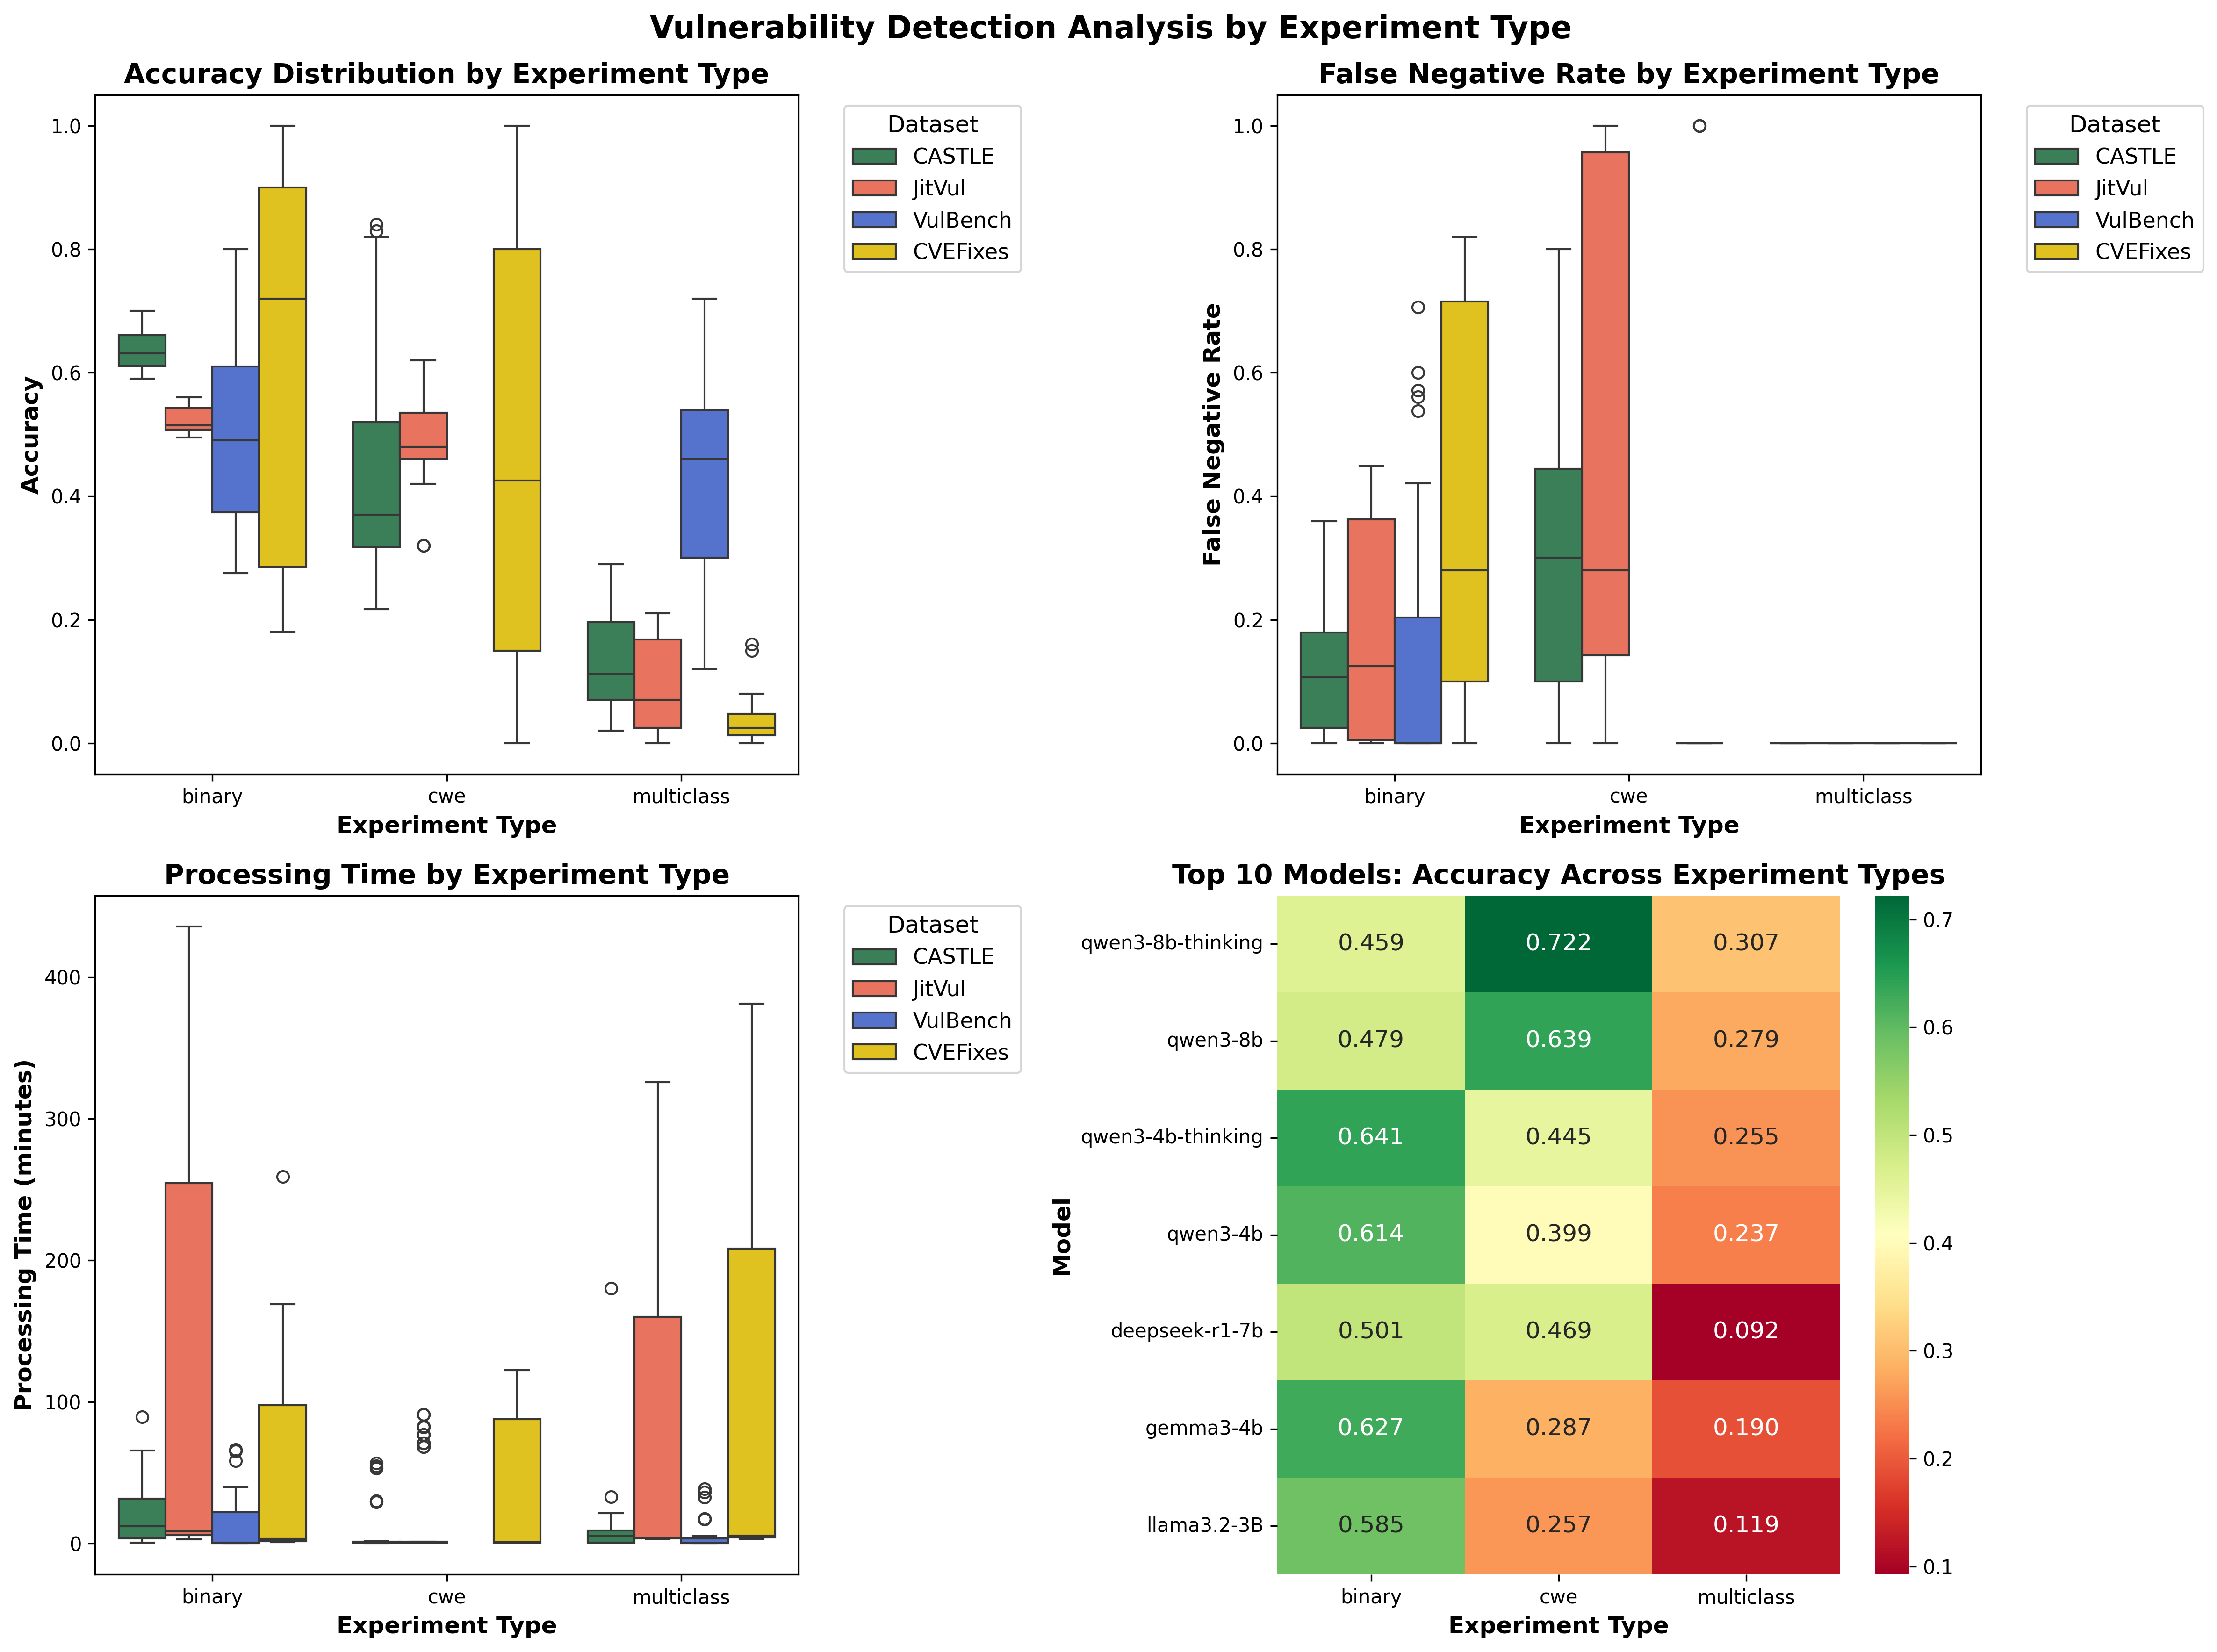


=== STATISTICAL INSIGHTS ===
Average Performance by Experiment Type:
                 accuracy  false_negative_rate  time_minutes
experiment_type                                             
binary             0.5698               0.1728       31.9698
cwe                0.4685               0.2788       19.7219
multiclass         0.2095               0.0000       38.8718

Models tested across multiple experiment types: 7

Top 5 Most Consistent Models (tested on multiple experiment types):
                   accuracy  false_negative_rate  experiment_type
model                                                            
qwen3-8b-thinking    0.5659               0.3755                3
qwen3-8b             0.5179               0.4327                3
qwen3-4b-thinking    0.4405               0.0697                3
qwen3-4b             0.4402               0.0848                3
deepseek-r1-7b       0.3847               0.1945                3

SCIENTIFIC CONCLUSIONS FOR PUBLICATION

🔬 

In [15]:
# 5. EXPERIMENT TYPE ANALYSIS (Binary, Multiclass, CWE-Specific)

print("=== ANALYSIS BY EXPERIMENT TYPE ===")
print("Comparing Binary vs Multiclass vs CWE-specific vulnerability detection")
print()

# Analyze performance by experiment type
experiment_analysis = all_results_df.groupby(['experiment_type', 'dataset']).agg({
    'accuracy': ['mean', 'std', 'count'],
    'false_negative_rate': ['mean', 'std'],
    'time_minutes': ['mean', 'std']
}).round(4)

print("Performance by Experiment Type and Dataset:")
print(experiment_analysis)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Vulnerability Detection Analysis by Experiment Type', fontsize=16, fontweight='bold')

# 5.1 Accuracy by Experiment Type
ax1 = axes[0, 0]
sns.boxplot(data=all_results_df, x='experiment_type', y='accuracy', hue='dataset', ax=ax1)
ax1.set_title('Accuracy Distribution by Experiment Type', fontweight='bold')
ax1.set_xlabel('Experiment Type', fontweight='bold')
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')

# 5.2 False Negative Rate by Experiment Type
ax2 = axes[0, 1]
sns.boxplot(data=all_results_df, x='experiment_type', y='false_negative_rate', hue='dataset', ax=ax2)
ax2.set_title('False Negative Rate by Experiment Type', fontweight='bold')
ax2.set_xlabel('Experiment Type', fontweight='bold')
ax2.set_ylabel('False Negative Rate', fontweight='bold')
ax2.legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')

# 5.3 Processing Time by Experiment Type
ax3 = axes[1, 0]
sns.boxplot(data=all_results_df, x='experiment_type', y='time_minutes', hue='dataset', ax=ax3)
ax3.set_title('Processing Time by Experiment Type', fontweight='bold')
ax3.set_xlabel('Experiment Type', fontweight='bold')
ax3.set_ylabel('Processing Time (minutes)', fontweight='bold')
ax3.legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')

# 5.4 Model Performance Across Experiment Types
ax4 = axes[1, 1]
pivot_data = all_results_df.pivot_table(
    values='accuracy', 
    index='model', 
    columns='experiment_type', 
    aggfunc='mean'
).fillna(0)

# Select top 10 models for clarity
top_models = all_results_df.groupby('model')['accuracy'].mean().sort_values(ascending=False).head(10).index
pivot_subset = pivot_data.loc[top_models]

sns.heatmap(pivot_subset, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax4)
ax4.set_title('Top 10 Models: Accuracy Across Experiment Types', fontweight='bold')
ax4.set_xlabel('Experiment Type', fontweight='bold')
ax4.set_ylabel('Model', fontweight='bold')

plt.tight_layout()
plt.show()

# Statistical analysis
print("\n=== STATISTICAL INSIGHTS ===")

# Best performing experiment type overall
exp_type_performance = all_results_df.groupby('experiment_type').agg({
    'accuracy': 'mean',
    'false_negative_rate': 'mean',
    'time_minutes': 'mean'
}).round(4)

print("Average Performance by Experiment Type:")
print(exp_type_performance)

# Find models that perform consistently well across all experiment types
models_all_types = all_results_df.groupby('model')['experiment_type'].nunique()
consistent_models = models_all_types[models_all_types >= 2].index  # Models tested on 2+ experiment types

if len(consistent_models) > 0:
    print(f"\nModels tested across multiple experiment types: {len(consistent_models)}")
    consistent_performance = all_results_df[all_results_df['model'].isin(consistent_models)].groupby('model').agg({
        'accuracy': 'mean',
        'false_negative_rate': 'mean',
        'experiment_type': 'nunique'
    }).sort_values('accuracy', ascending=False)
    
    print("\nTop 5 Most Consistent Models (tested on multiple experiment types):")
    print(consistent_performance.head().round(4))

# 6. SCIENTIFIC CONCLUSIONS AND RECOMMENDATIONS

print("\n" + "="*80)
print("SCIENTIFIC CONCLUSIONS FOR PUBLICATION")
print("="*80)

print("\n🔬 KEY FINDINGS:")

print("\n1. BEST OVERALL PERFORMERS:")
top_3_models = model_rankings.head(3)
for i, (model, data) in enumerate(top_3_models.iterrows(), 1):
    print(f"   {i}. {model}")
    print(f"      • Overall Score: {data['performance_score']:.3f}")
    print(f"      • Accuracy: {data['accuracy']:.3f}")
    print(f"      • False Negative Rate: {data['false_negative_rate']:.3f}")

print("\n2. SECURITY ANALYSIS (False Negative Focus):")
safest_models = all_results_df.groupby('model')['false_negative_rate'].mean().sort_values().head(3)
for i, (model, fnr) in enumerate(safest_models.items(), 1):
    accuracy = all_results_df[all_results_df['model'] == model]['accuracy'].mean()
    print(f"   {i}. {model}: {fnr:.3f} FNR, {accuracy:.3f} Accuracy")

print("\n3. EFFICIENCY LEADERS:")
efficient_models = model_rankings.sort_values('accuracy_per_time', ascending=False).head(3)
for i, (model, data) in enumerate(efficient_models.iterrows(), 1):
    print(f"   {i}. {model}: {data['accuracy_per_time']:.4f} accuracy/minute")

print("\n4. DATASET COMPARISON:")
dataset_stats = all_results_df.groupby('dataset').agg({
    'accuracy': 'mean',
    'false_negative_rate': 'mean'
}).round(3)
for dataset, stats in dataset_stats.iterrows():
    print(f"   • {dataset}: {stats['accuracy']:.3f} avg accuracy, {stats['false_negative_rate']:.3f} avg FNR")

print("\n📊 PUBLICATION RECOMMENDATIONS:")
print("   • Include heatmaps showing model×dataset performance matrix")
print("   • Emphasize false negative analysis for security implications") 
print("   • Present efficiency analysis for practical deployment guidance")
print("   • Highlight trade-offs between accuracy, security, and computational cost")
print("   • Recommend specific models for different use cases (production vs research)")

print("\n⚠️  CRITICAL SECURITY WARNINGS:")
high_fnr_count = len(all_results_df[all_results_df['false_negative_rate'] > 0.3])
total_experiments = len(all_results_df)
print(f"   • {high_fnr_count}/{total_experiments} experiments had >30% false negative rate")
print("   • High FNR means missing vulnerabilities - unacceptable for production security")
print("   • Recommend only models with <10% FNR for security-critical applications")

print("\n🎯 FUTURE RESEARCH DIRECTIONS:")
print("   • Investigate ensemble methods to reduce false negatives")
print("   • Analyze performance on specific CWE categories")
print("   • Study impact of prompt engineering on security performance")
print("   • Develop specialized models for critical vulnerability types")

In [14]:
# Aggregate Metrics Across Experiments and Benchmarks
def aggregate_metrics(df):
    """Aggregate performance metrics by LLM, dataset, and experiment type"""
    
    # Group by LLM and dataset for overall performance - this is the main table you requested
    agg_by_llm_dataset = df.groupby(['model', 'dataset', 'experiment_type']).agg({
        'accuracy': 'mean',
        'precision': 'mean', 
        'recall': 'mean',
        'f1_score': 'mean',
        'specificity': 'mean',
        'false_negatives': 'sum',
        'true_positives': 'sum',
        'true_negatives': 'sum',
        'false_positives': 'sum',
        'total_samples': 'sum',
        'total_time': 'sum'
    }).round(4)
    
    # Group by LLM for overall performance across all datasets
    agg_by_llm = df.groupby('model').agg({
        'accuracy': 'mean',
        'precision': 'mean',
        'recall': 'mean', 
        'f1_score': 'mean',
        'specificity': 'mean',
        'false_negatives': 'sum',
        'true_positives': 'sum',
        'true_negatives': 'sum',
        'false_positives': 'sum',
        'total_samples': 'sum',
        'total_time': 'sum'
    }).round(4)
    
    # Group by LLM and experiment type
    agg_by_llm_exp_type = df.groupby(['model', 'experiment_type']).agg({
        'accuracy': 'mean',
        'precision': 'mean',
        'recall': 'mean',
        'f1_score': 'mean',
        'specificity': 'mean', 
        'false_negatives': 'sum',
        'total_samples': 'sum',
        'total_time': 'sum'
    }).round(4)
    
    # Calculate efficiency metrics (accuracy per second)
    agg_by_llm['efficiency'] = (agg_by_llm['accuracy'] / (agg_by_llm['total_time'] / 3600)).round(6)  # accuracy per hour
    agg_by_llm_dataset['efficiency'] = (agg_by_llm_dataset['accuracy'] / (agg_by_llm_dataset['total_time'] / 3600)).round(6)
    
    return agg_by_llm, agg_by_llm_dataset, agg_by_llm_exp_type

# Perform aggregation
print("Aggregating metrics across experiments...")
agg_llm, agg_llm_dataset, agg_llm_exp_type = aggregate_metrics(all_results_df)

# Display the main table you requested: model-dataset combinations with metrics
print("\n📊 COMPREHENSIVE MODEL-DATASET PERFORMANCE TABLE:")
print("=" * 80)
print("Rows: Model-Dataset combinations | Columns: Performance metrics")
print("=" * 80)

# Create a clean display of the model-dataset aggregation
model_dataset_table = agg_llm_dataset[['accuracy', 'precision', 'recall', 'f1_score', 'false_negatives', 'total_time']].copy()
# model_dataset_table['total_time_hours'] = (model_dataset_table['total_time'] / 3600).round(2)
model_dataset_table = model_dataset_table.drop('total_time', axis=1)

print(model_dataset_table)

# Save to CSV for easy analysis
model_dataset_table.to_csv('model_dataset_performance.csv')
print(f"\n💾 Table saved to: model_dataset_performance.csv")

# Calculate some key statistics
print("\n📈 Key Performance Statistics:")
print(f"🎯 Best overall accuracy: {agg_llm['accuracy'].max():.3f} ({agg_llm['accuracy'].idxmax()})")
print(f"⚡ Most efficient model: {agg_llm['efficiency'].idxmax()} (efficiency: {agg_llm['efficiency'].max():.6f})")
print(f"🚨 Lowest false negatives: {agg_llm['false_negatives'].min()} ({agg_llm['false_negatives'].idxmin()})")
print(f"⏱️ Fastest model: {agg_llm['total_time'].idxmin()} ({agg_llm['total_time'].min():.1f}s total)")

# Display top performers from the model-dataset table
print("\n🏆 Top 10 Model-Dataset Combinations by Accuracy:")
top_combinations = model_dataset_table.sort_values('accuracy', ascending=False).head(10)
print(top_combinations)

print("\n🚨 Model-Dataset Combinations with Lowest False Negatives:")
lowest_fn_combinations = model_dataset_table.sort_values('false_negatives').head(10)
print(lowest_fn_combinations)

# print("\n⚡ Most Efficient Model-Dataset Combinations (by processing time):")
# fastest_combinations = model_dataset_table.sort_values('total_time_hours').head(10)
# print(fastest_combinations)

Aggregating metrics across experiments...

📊 COMPREHENSIVE MODEL-DATASET PERFORMANCE TABLE:
Rows: Model-Dataset combinations | Columns: Performance metrics
                                            accuracy  precision  recall  \
model             dataset  experiment_type                                
deepseek-r1-7b    CASTLE   binary             0.6300     0.6769  0.7333   
                           cwe                0.5125     0.1161  0.5889   
                           multiclass         0.0900     0.0000  0.0000   
                  CVEFixes binary             0.5100     1.0000  0.5100   
                           cwe                0.3333     0.0128  0.1667   
...                                              ...        ...     ...   
qwen3-8b-thinking JitVul   binary             0.5450     0.5897  0.6161   
                           cwe                0.5000     0.4167  0.0287   
                           multiclass         0.1500     0.0000  0.0000   
                  V

Creating performance metric visualizations...


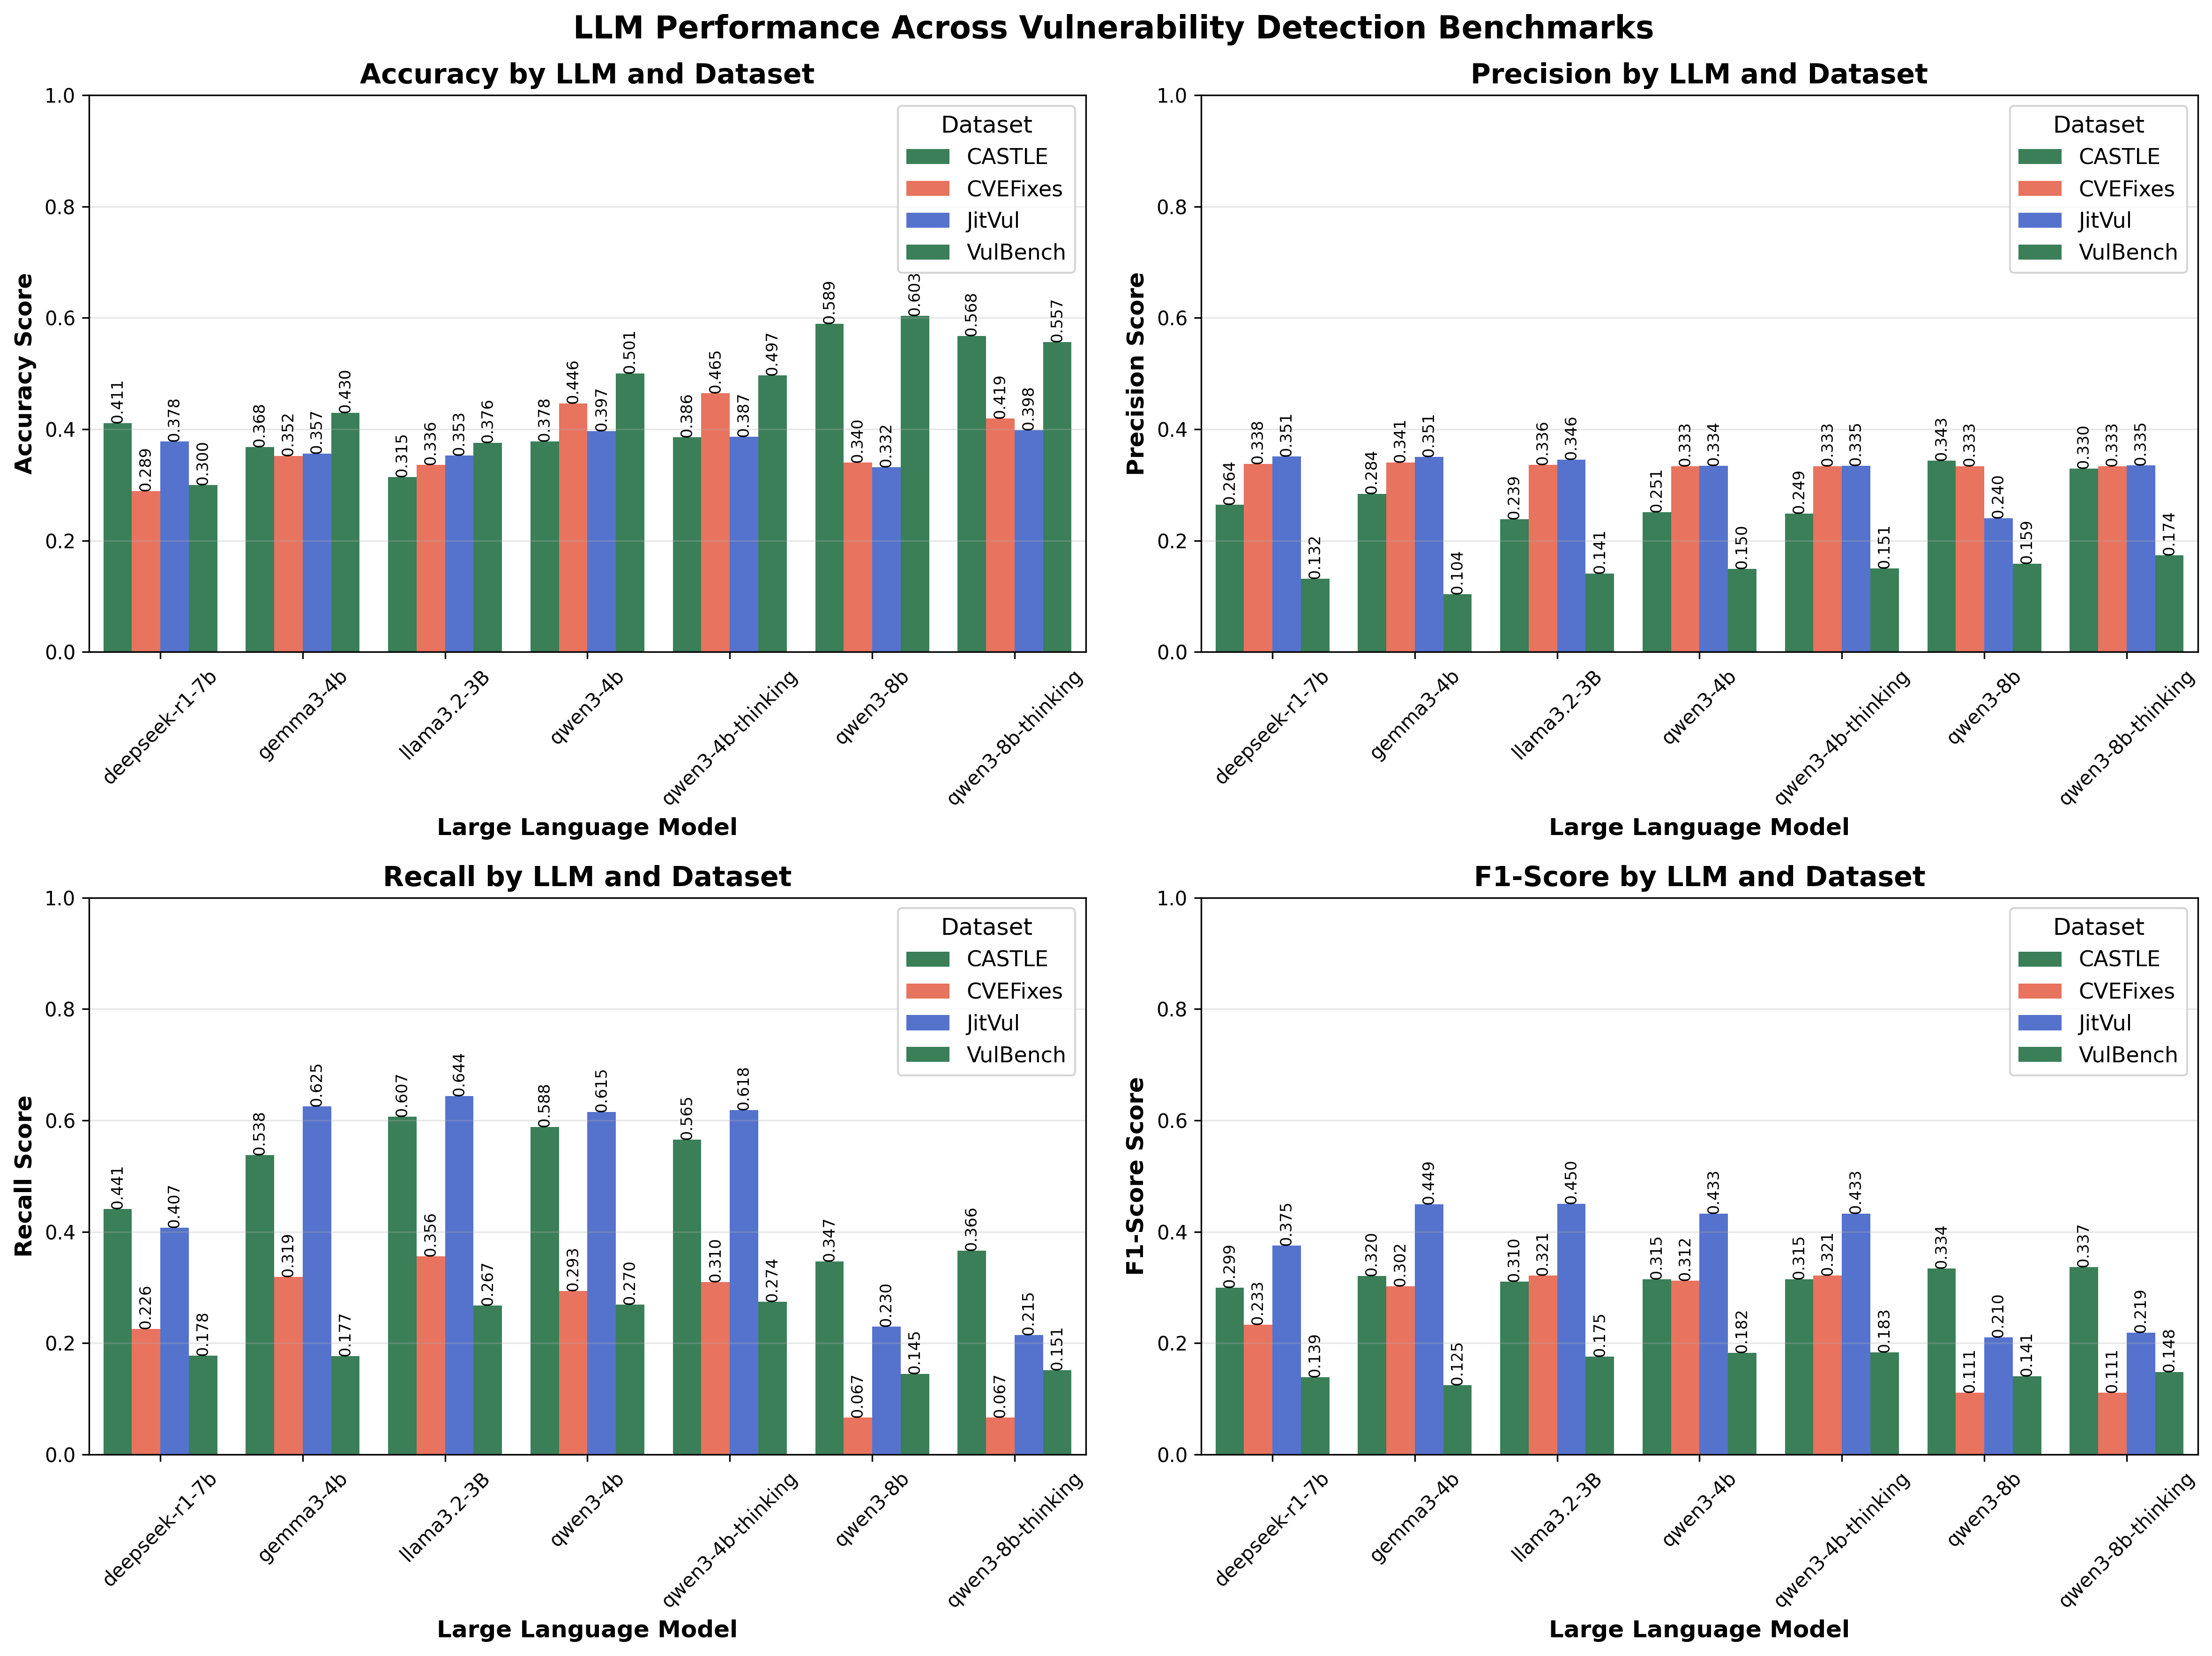

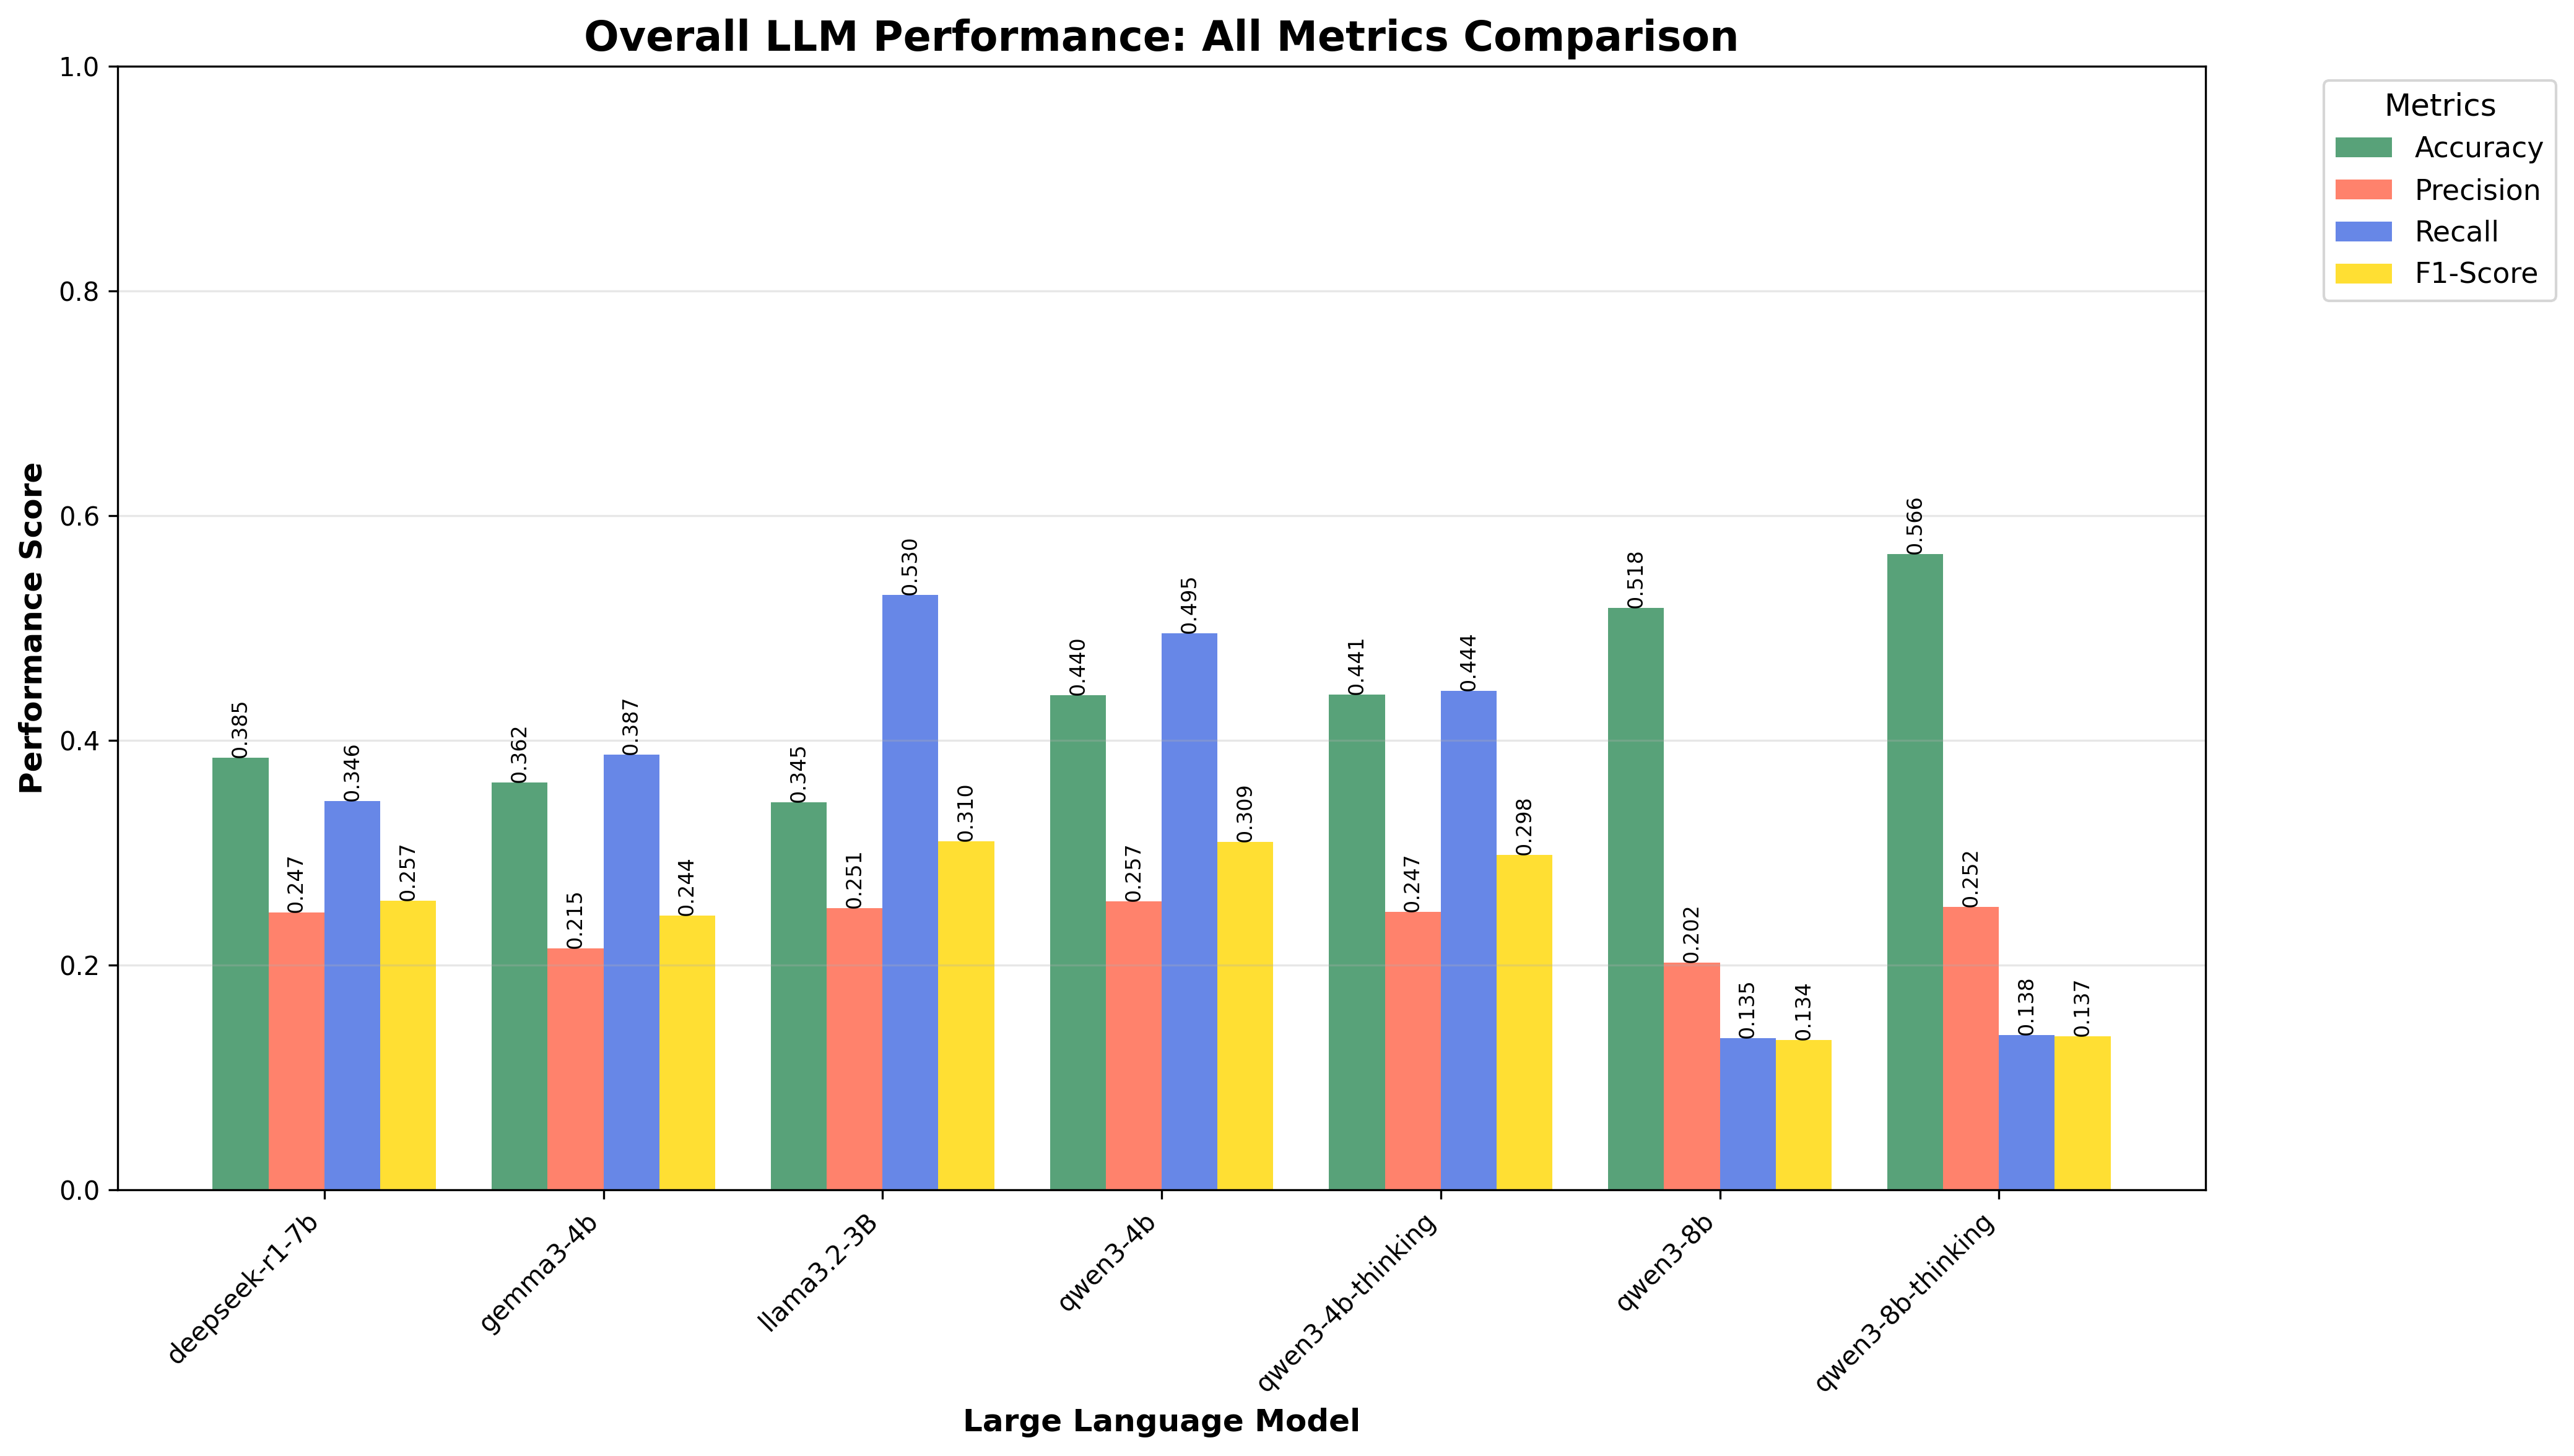

✅ Performance visualizations completed


In [11]:
# Visualize Accuracy, Precision, Recall, F1-Score for Each LLM and Benchmark
def plot_performance_metrics():
    """Create comprehensive performance visualizations for publication"""
    
    # Prepare data for visualization
    viz_data = agg_llm_dataset.reset_index()
    
    # Create subplots for different metrics
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('LLM Performance Across Vulnerability Detection Benchmarks', fontsize=16, fontweight='bold')
    
    metrics = ['accuracy', 'precision', 'recall', 'f1_score']
    metric_titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    
    for idx, (metric, title) in enumerate(zip(metrics, metric_titles)):
        ax = axes[idx // 2, idx % 2]
        
        # Create grouped bar plot
        sns.barplot(data=viz_data, x='model', y=metric, hue='dataset', ax=ax, palette=colors[:3], errorbar=None)
        
        ax.set_title(f'{title} by LLM and Dataset', fontweight='bold', fontsize=14)
        ax.set_xlabel('Large Language Model', fontweight='bold')
        ax.set_ylabel(f'{title} Score', fontweight='bold')
        ax.set_ylim(0, 1.0)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Rotate x-axis labels for better readability
        ax.tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for container in ax.containers:
            ax.bar_label(container, fmt='%.3f', rotation=90, fontsize=8)
        
        # Customize legend
        ax.legend(title='Dataset',  loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    # Overall performance comparison
    fig, ax = plt.subplots(1, 1, figsize=(14, 8))
    
    # Prepare data for overall comparison
    overall_data = agg_llm.reset_index()
    
    # Create grouped bar plot for all metrics
    x = np.arange(len(overall_data))
    width = 0.2
    
    bars1 = ax.bar(x - 1.5*width, overall_data['accuracy'], width, label='Accuracy', alpha=0.8, color=colors[0])
    bars2 = ax.bar(x - 0.5*width, overall_data['precision'], width, label='Precision', alpha=0.8, color=colors[1])
    bars3 = ax.bar(x + 0.5*width, overall_data['recall'], width, label='Recall', alpha=0.8, color=colors[2])
    bars4 = ax.bar(x + 1.5*width, overall_data['f1_score'], width, label='F1-Score', alpha=0.8, color=colors[3])
    
    ax.set_title('Overall LLM Performance: All Metrics Comparison', fontweight='bold', fontsize=16)
    ax.set_xlabel('Large Language Model', fontweight='bold', fontsize=12)
    ax.set_ylabel('Performance Score', fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(overall_data['model'], rotation=45, ha='right')
    ax.set_ylim(0, 1.0)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add value labels
    for bars in [bars1, bars2, bars3, bars4]:
        ax.bar_label(bars, fmt='%.3f', rotation=90, fontsize=8)
    
    plt.tight_layout()
    plt.show()

# Create performance visualizations
print("Creating performance metric visualizations...")
plot_performance_metrics()
print("✅ Performance visualizations completed")

Creating false negatives analysis (Critical for Security)...


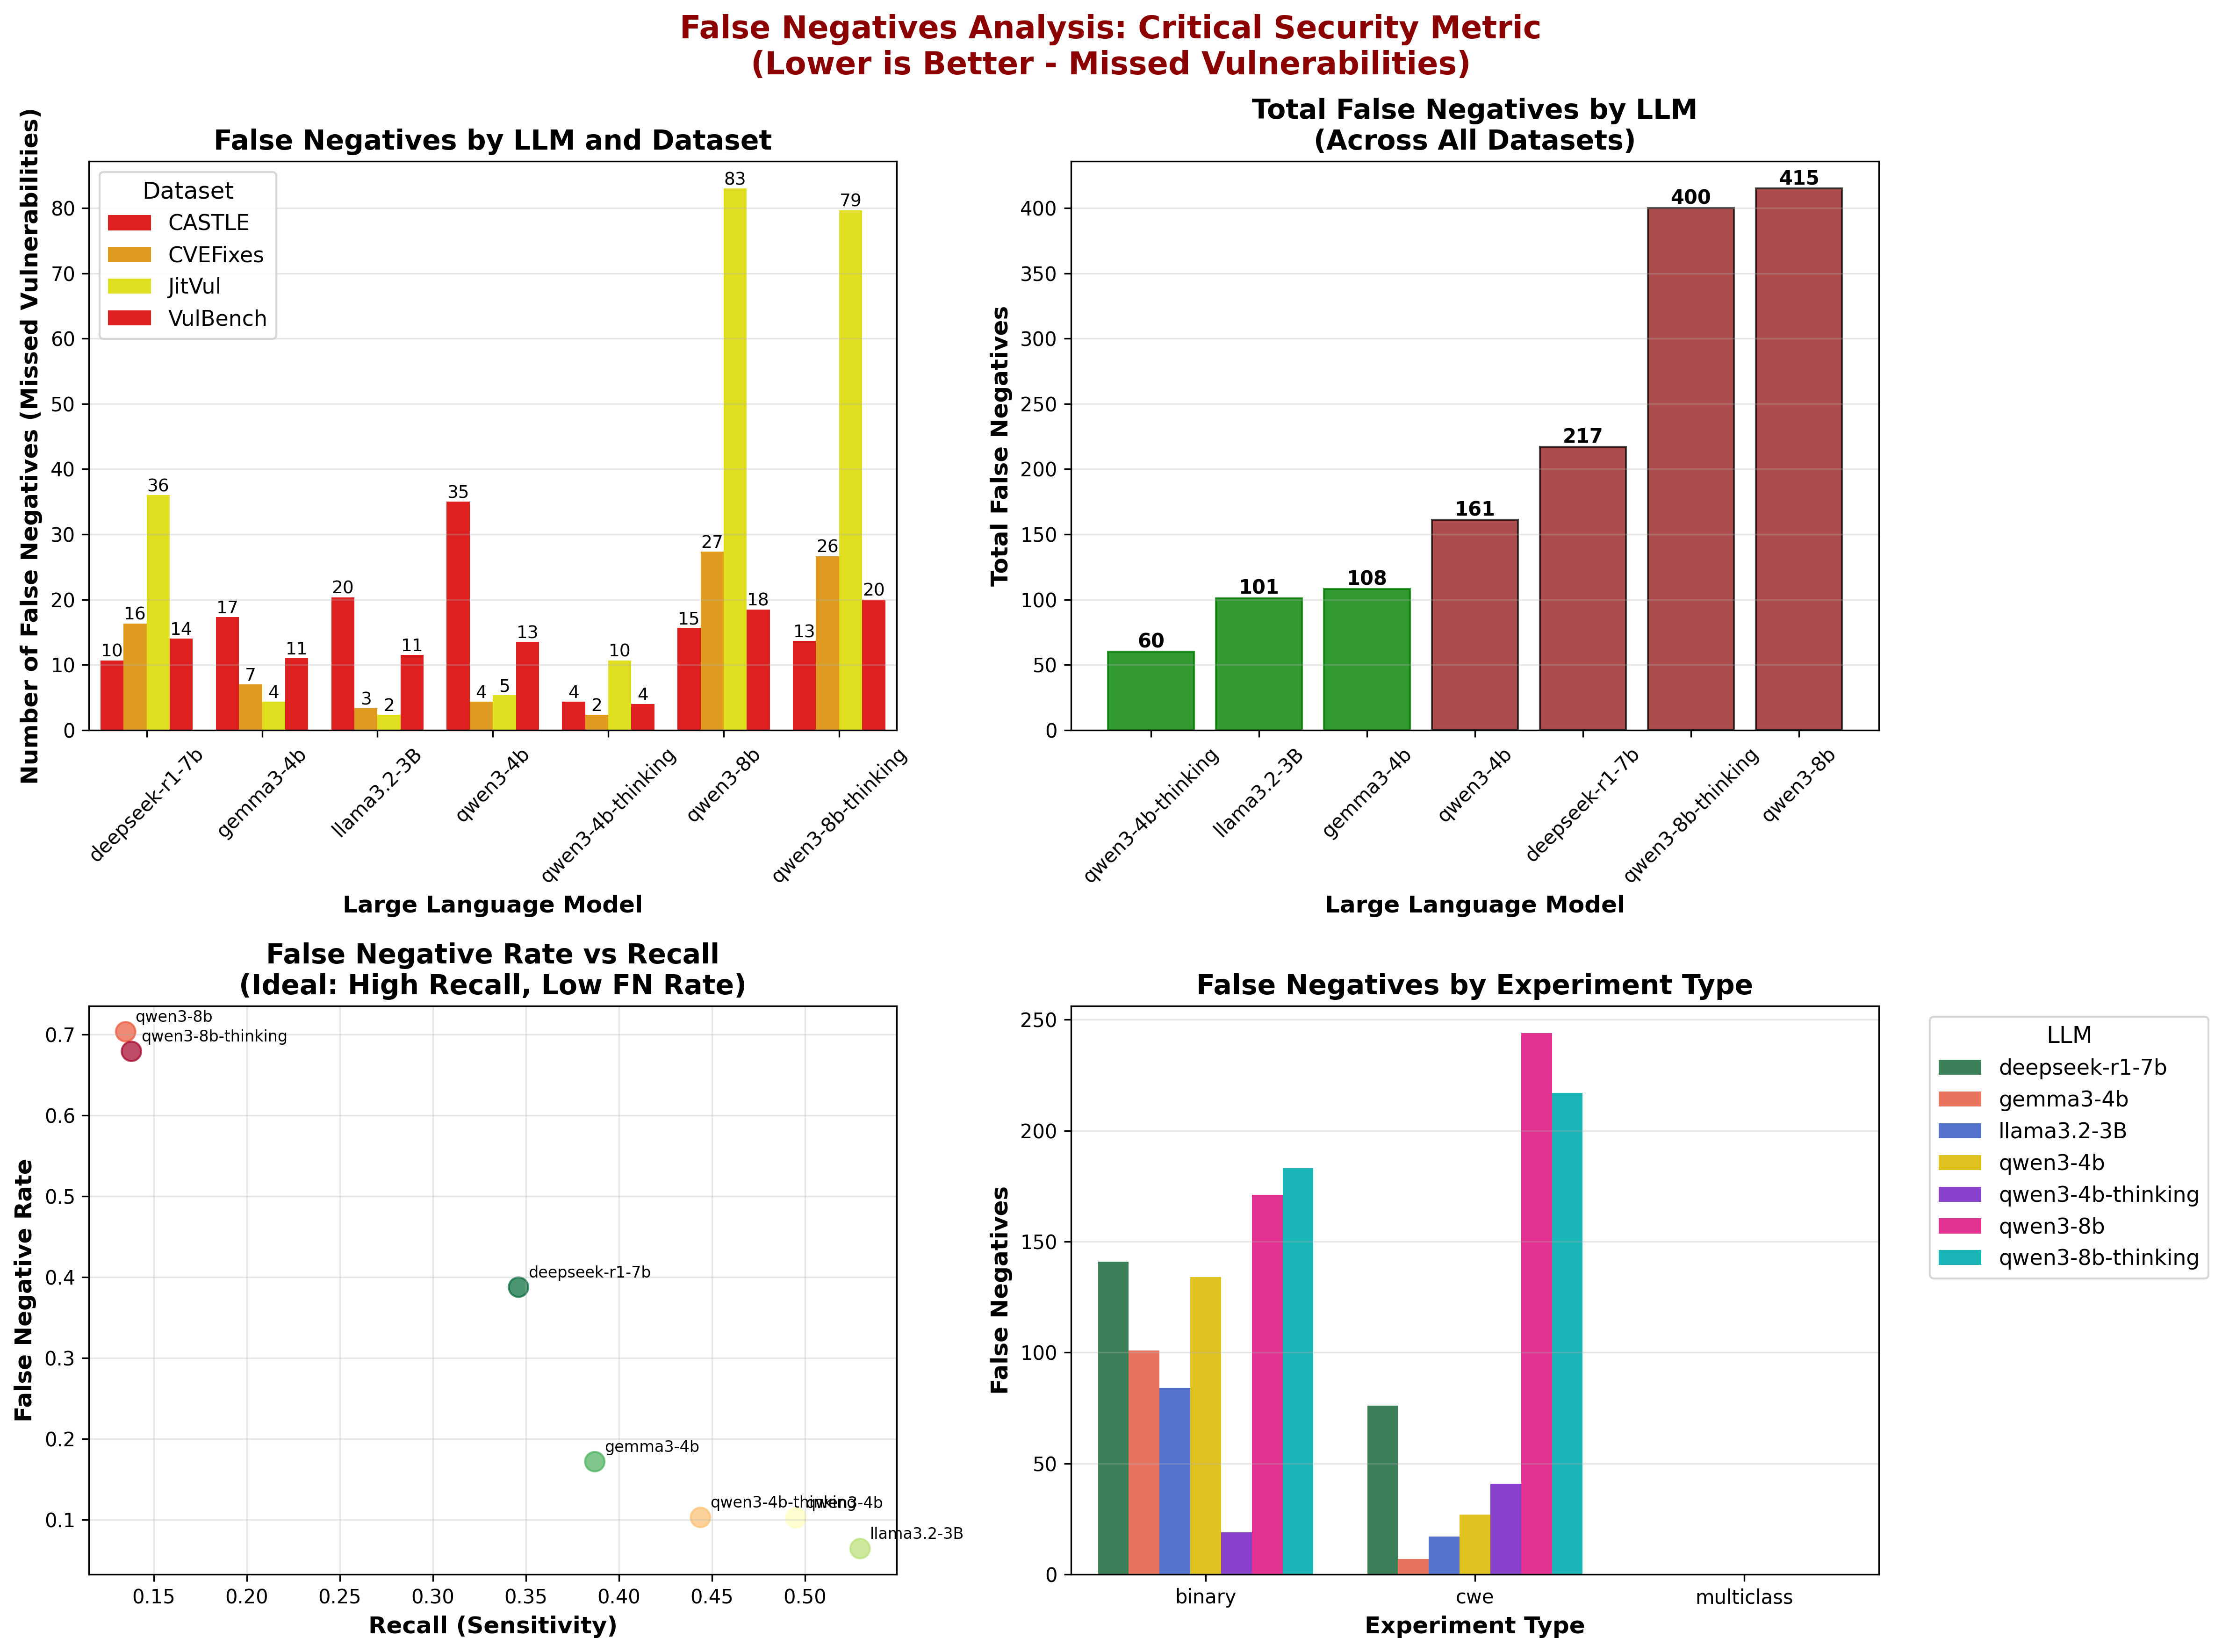

🚨 CRITICAL FALSE NEGATIVES ANALYSIS:
🏆 Best LLM (Lowest FN): qwen3-4b-thinking (60 missed vulnerabilities)
⚠️  Worst LLM (Highest FN): qwen3-8b (415 missed vulnerabilities)
📊 Lowest FN Rate: llama3.2-3B (0.064)
📊 Highest FN Rate: qwen3-8b (0.703)
✅ False negatives analysis completed


In [12]:
# Visualize False Negatives for Each LLM (Critical for Vulnerability Detection)
def plot_false_negatives_analysis():
    """Create detailed false negatives visualizations - critical for security analysis"""
    
    # Create comprehensive false negatives analysis
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('False Negatives Analysis: Critical Security Metric\n(Lower is Better - Missed Vulnerabilities)', 
                 fontsize=16, fontweight='bold', color='darkred')
    
    # 1. False negatives by LLM across datasets
    ax1 = axes[0, 0]
    fn_by_dataset = agg_llm_dataset.reset_index()
    sns.barplot(data=fn_by_dataset, x='model', y='false_negatives', hue='dataset', errorbar=None, ax=ax1, palette=['red', 'orange', 'yellow'])
    ax1.set_title('False Negatives by LLM and Dataset', fontweight='bold')
    ax1.set_xlabel('Large Language Model', fontweight='bold')
    ax1.set_ylabel('Number of False Negatives (Missed Vulnerabilities)', fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.legend(title='Dataset')
    
    # Add value labels
    for container in ax1.containers:
        ax1.bar_label(container, fmt='%d', fontsize=9)
    
    # 2. Overall false negatives by LLM
    ax2 = axes[0, 1]
    overall_fn = agg_llm.reset_index().sort_values('false_negatives')
    bars = ax2.bar(overall_fn['model'], overall_fn['false_negatives'], 
                   color='darkred', alpha=0.7, edgecolor='black')
    ax2.set_title('Total False Negatives by LLM\n(Across All Datasets)', fontweight='bold')
    ax2.set_xlabel('Large Language Model', fontweight='bold')
    ax2.set_ylabel('Total False Negatives', fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Highlight the best performers (lowest FN)
    for i, bar in enumerate(bars):
        if i < 3:  # Top 3 performers
            bar.set_color('green')
            bar.set_alpha(0.8)
    
    ax2.bar_label(bars, fmt='%d', fontsize=10, fontweight='bold')
    
    # 3. False Negative Rate vs Recall
    ax3 = axes[1, 0]
    fn_rate_data = agg_llm.reset_index()
    fn_rate_data['fn_rate'] = fn_rate_data['false_negatives'] / (fn_rate_data['false_negatives'] + fn_rate_data['true_positives'])
    
    scatter = ax3.scatter(fn_rate_data['recall'], fn_rate_data['fn_rate'], 
                         s=100, alpha=0.7, c=range(len(fn_rate_data)), cmap='RdYlGn_r')
    ax3.set_title('False Negative Rate vs Recall\n(Ideal: High Recall, Low FN Rate)', fontweight='bold')
    ax3.set_xlabel('Recall (Sensitivity)', fontweight='bold')
    ax3.set_ylabel('False Negative Rate', fontweight='bold')
    ax3.grid(True, alpha=0.3)
    
    # Annotate points with LLM names
    for i, row in fn_rate_data.iterrows():
        ax3.annotate(row['model'], (row['recall'], row['fn_rate']), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    # 4. False negatives by experiment type
    ax4 = axes[1, 1]
    fn_by_exp_type = agg_llm_exp_type.reset_index()
    sns.barplot(data=fn_by_exp_type, x='experiment_type', y='false_negatives', 
                hue='model', ax=ax4, palette=colors)
    ax4.set_title('False Negatives by Experiment Type', fontweight='bold')
    ax4.set_xlabel('Experiment Type', fontweight='bold')
    ax4.set_ylabel('False Negatives', fontweight='bold')
    ax4.legend(title='LLM', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Critical insights summary
    print("🚨 CRITICAL FALSE NEGATIVES ANALYSIS:")
    print("=" * 60)
    print(f"🏆 Best LLM (Lowest FN): {overall_fn.iloc[0]['model']} ({overall_fn.iloc[0]['false_negatives']} missed vulnerabilities)")
    print(f"⚠️  Worst LLM (Highest FN): {overall_fn.iloc[-1]['model']} ({overall_fn.iloc[-1]['false_negatives']} missed vulnerabilities)")
    
    # Calculate false negative rates
    fn_rates = []
    for _, row in agg_llm.iterrows():
        total_actual_positives = row['false_negatives'] + row['true_positives']
        if total_actual_positives > 0:
            fn_rate = row['false_negatives'] / total_actual_positives
            fn_rates.append((row.name, fn_rate))
    
    if fn_rates:
        fn_rates.sort(key=lambda x: x[1])
        print(f"📊 Lowest FN Rate: {fn_rates[0][0]} ({fn_rates[0][1]:.3f})")
        print(f"📊 Highest FN Rate: {fn_rates[-1][0]} ({fn_rates[-1][1]:.3f})")

# Create false negatives analysis
print("Creating false negatives analysis (Critical for Security)...")
plot_false_negatives_analysis()
print("✅ False negatives analysis completed")

Creating computational efficiency analysis...
Index(['model', 'dataset', 'experiment_type', 'accuracy', 'precision',
       'recall', 'f1_score', 'specificity', 'false_negatives',
       'true_positives', 'true_negatives', 'false_positives', 'total_samples',
       'total_time', 'efficiency'],
      dtype='object')


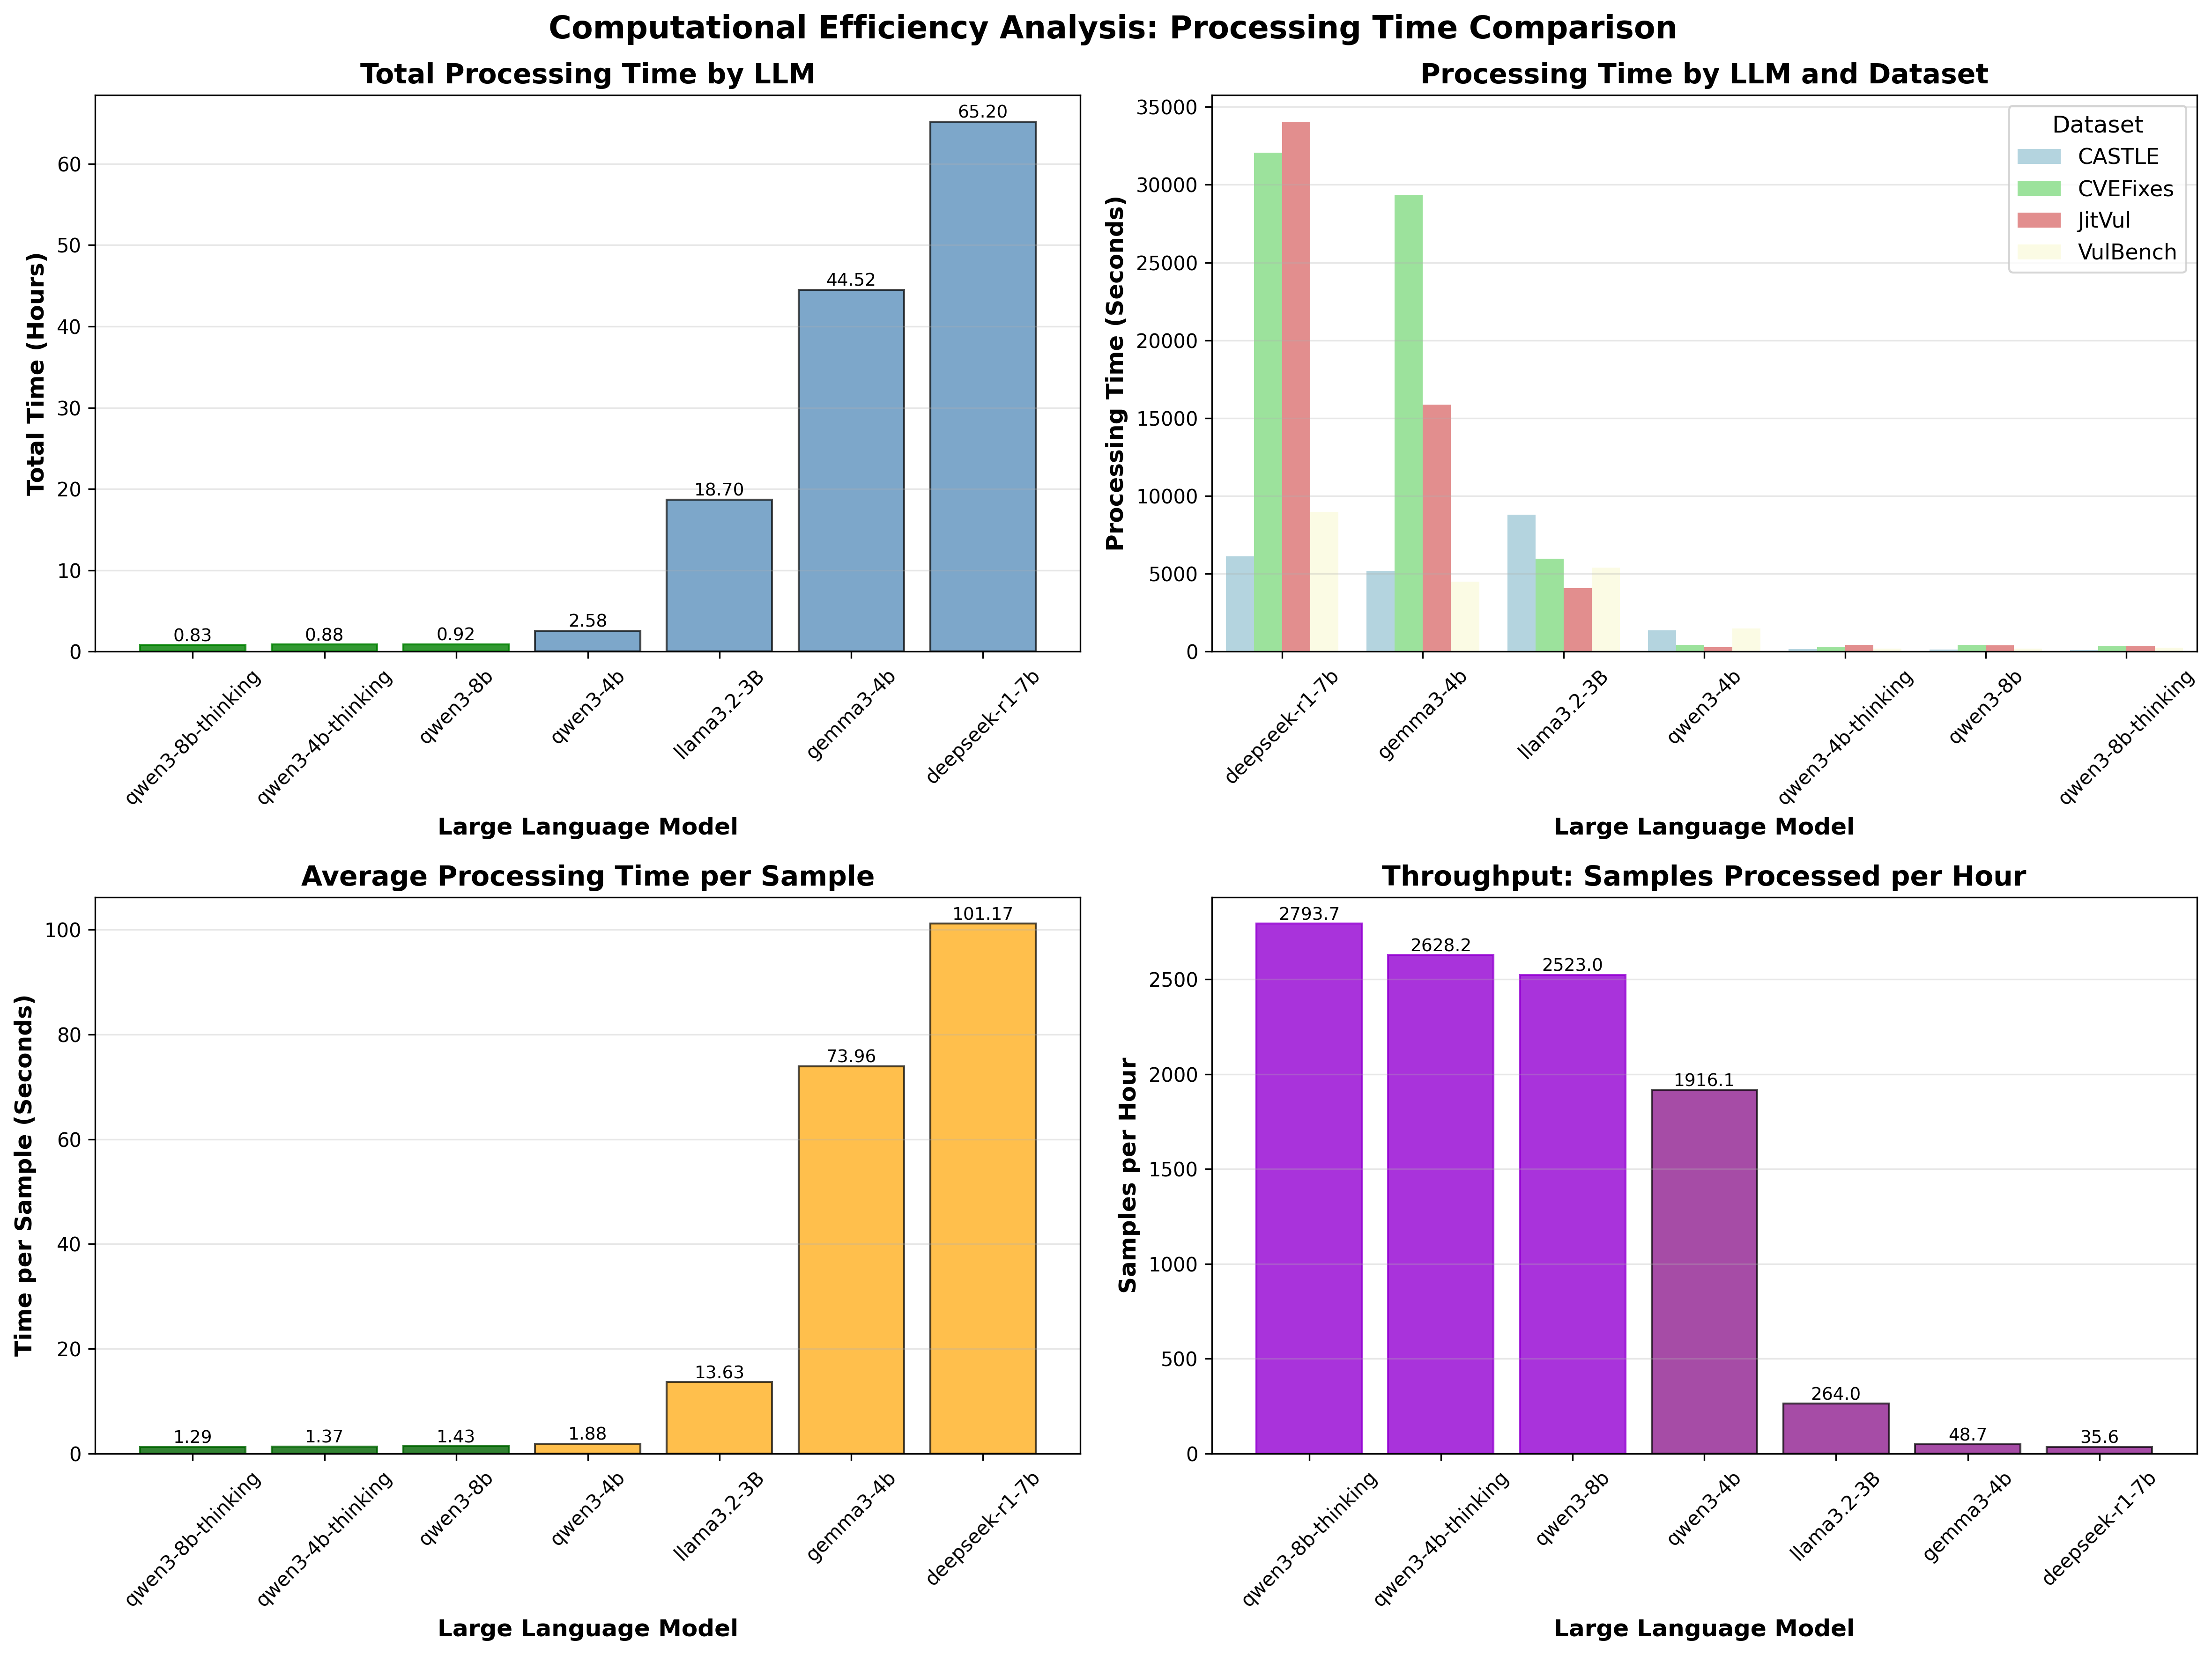

⏱️ COMPUTATIONAL EFFICIENCY INSIGHTS:
🏎️  Fastest Overall: qwen3-8b-thinking (0.83 hours)
🐌 Slowest Overall: deepseek-r1-7b (65.20 hours)
⚡ Most Efficient: qwen3-8b-thinking (1.29 sec/sample)
🚀 Highest Throughput: qwen3-8b-thinking (2793.7 samples/hour)
📊 Speed Difference: 78.5x faster (fastest vs slowest)
✅ Duration analysis completed


In [16]:
# Visualize Total Duration for Each LLM
def plot_duration_analysis():
    """Analyze computational efficiency and processing time across LLMs"""
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Computational Efficiency Analysis: Processing Time Comparison', 
                 fontsize=16, fontweight='bold')
    
    # 1. Total processing time by LLM
    ax1 = axes[0, 0]
    time_data = agg_llm.reset_index().sort_values('total_time')
    bars = ax1.bar(time_data['model'], time_data['total_time'] / 3600, 
                   color='steelblue', alpha=0.7, edgecolor='black')
    ax1.set_title('Total Processing Time by LLM', fontweight='bold')
    ax1.set_xlabel('Large Language Model', fontweight='bold')
    ax1.set_ylabel('Total Time (Hours)', fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Highlight fastest models
    for i, bar in enumerate(bars):
        if i < 3:  # Top 3 fastest
            bar.set_color('green')
            bar.set_alpha(0.8)
    
    ax1.bar_label(bars, fmt='%.2f', fontsize=9)
    
    # 2. Processing time by dataset
    ax2 = axes[0, 1]
    time_by_dataset = agg_llm_dataset.reset_index()
    print(time_by_dataset.columns)
    sns.barplot(data=time_by_dataset, x='model', y='total_time', hue='dataset', errorbar=None,
                ax=ax2, palette=['lightblue', 'lightgreen', 'lightcoral', 'lightyellow'])
    ax2.set_title('Processing Time by LLM and Dataset', fontweight='bold')
    ax2.set_xlabel('Large Language Model', fontweight='bold')
    ax2.set_ylabel('Processing Time (Seconds)', fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    ax2.legend(title='Dataset')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3. Time per sample analysis
    ax3 = axes[1, 0]
    time_per_sample = agg_llm.reset_index()
    time_per_sample['time_per_sample'] = time_per_sample['total_time'] / time_per_sample['total_samples']
    time_per_sample = time_per_sample.sort_values('time_per_sample')
    
    bars = ax3.bar(time_per_sample['model'], time_per_sample['time_per_sample'], 
                   color='orange', alpha=0.7, edgecolor='black')
    ax3.set_title('Average Processing Time per Sample', fontweight='bold')
    ax3.set_xlabel('Large Language Model', fontweight='bold')
    ax3.set_ylabel('Time per Sample (Seconds)', fontweight='bold')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Highlight most efficient models
    for i, bar in enumerate(bars):
        if i < 3:  # Top 3 most efficient
            bar.set_color('darkgreen')
            bar.set_alpha(0.8)
    
    ax3.bar_label(bars, fmt='%.2f', fontsize=9)
    
    # 4. Samples processed per hour
    ax4 = axes[1, 1]
    throughput_data = agg_llm.reset_index()
    throughput_data['samples_per_hour'] = throughput_data['total_samples'] / (throughput_data['total_time'] / 3600)
    throughput_data = throughput_data.sort_values('samples_per_hour', ascending=False)
    
    bars = ax4.bar(throughput_data['model'], throughput_data['samples_per_hour'], 
                   color='purple', alpha=0.7, edgecolor='black')
    ax4.set_title('Throughput: Samples Processed per Hour', fontweight='bold')
    ax4.set_xlabel('Large Language Model', fontweight='bold')
    ax4.set_ylabel('Samples per Hour', fontweight='bold')
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Highlight highest throughput models
    for i, bar in enumerate(bars):
        if i < 3:  # Top 3 highest throughput
            bar.set_color('darkviolet')
            bar.set_alpha(0.8)
    
    ax4.bar_label(bars, fmt='%.1f', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Performance insights
    print("⏱️ COMPUTATIONAL EFFICIENCY INSIGHTS:")
    print("=" * 50)
    fastest_model = time_data.iloc[0]
    slowest_model = time_data.iloc[-1]
    most_efficient = time_per_sample.iloc[0]
    highest_throughput = throughput_data.iloc[0]
    
    print(f"🏎️  Fastest Overall: {fastest_model['model']} ({fastest_model['total_time']/3600:.2f} hours)")
    print(f"🐌 Slowest Overall: {slowest_model['model']} ({slowest_model['total_time']/3600:.2f} hours)")
    print(f"⚡ Most Efficient: {most_efficient['model']} ({most_efficient['time_per_sample']:.2f} sec/sample)")
    print(f"🚀 Highest Throughput: {highest_throughput['model']} ({highest_throughput['samples_per_hour']:.1f} samples/hour)")
    
    speed_ratio = slowest_model['total_time'] / fastest_model['total_time']
    print(f"📊 Speed Difference: {speed_ratio:.1f}x faster (fastest vs slowest)")

# Create duration analysis
print("Creating computational efficiency analysis...")
plot_duration_analysis()
print("✅ Duration analysis completed")